In [2]:
import pandas as pd

pairs_df = pd.read_csv("../data/processed/mises_co_citations_per_paragraph.csv")

pairs_df.head()

C:\Users\pedro\AppData\Local\Temp\ipykernel_11632\46695541.py:3: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  pairs_df = pd.read_csv("../data/processed/mises_co_citations_per_paragraph.csv")


,author_mises_citation,section_id,paragraph_id_mises_citation,sentence_id_mises_citation,page,human_action_chapter_number,human_action_part_number,context_mises_citation,author_citation,paragraph_id_citation,sentence_id_citation,context_citation
0,Mises,_4dGvzna,_97b4QYq,_dz5ekbM,1.0,0,0,The practitioners of methodological holism are...,Mises,_97b4QYq,_CDn7Hdd,Mises (1996Mises ( [1949]]) began his seminal ...
1,Mises,_4dGvzna,_97b4QYq,_dz5ekbM,1.0,0,0,The practitioners of methodological holism are...,Mises,_97b4QYq,_dz5ekbM,The practitioners of methodological holism are...
2,Mises,_4dGvzna,_97b4QYq,_dz5ekbM,1.0,0,0,The practitioners of methodological holism are...,Mises,_97b4QYq,_C6Yctzm,"Consequently the holistic philosophers ""could ..."
3,Mises,_4dGvzna,_97b4QYq,_dz5ekbM,1.0,0,0,The practitioners of methodological holism are...,Mises,_SJMxtyt,_HmUdX2X,This boundary establishes a distinction betwee...
4,Mises,_4dGvzna,_97b4QYq,_dz5ekbM,1.0,0,0,The practitioners of methodological holism are...,Christainsen,_SJMxtyt,_sDasGa2,This thinking is apparent in Hayek's response ...


In [3]:
pairs_df['human_action_chapter_number'].value_counts()

human_action_chapter_number
WHOLE    840721
8         78749
2         58956
7         31843
15        29450
1         28746
16        20354
16        18555
6         17051
17        17016
9         15511
13        14473
0         13354
20         9631
14         8808
18         8394
3          2744
5          2534
12         2209
4          2200
11         1692
26         1094
27          838
23          830
10          805
25          531
24          523
19          428
21          359
38          320
37          308
31          296
22          285
39          278
35          241
36          211
29          204
32          194
30          164
34           67
28           28
33            9
Name: count, dtype: int64

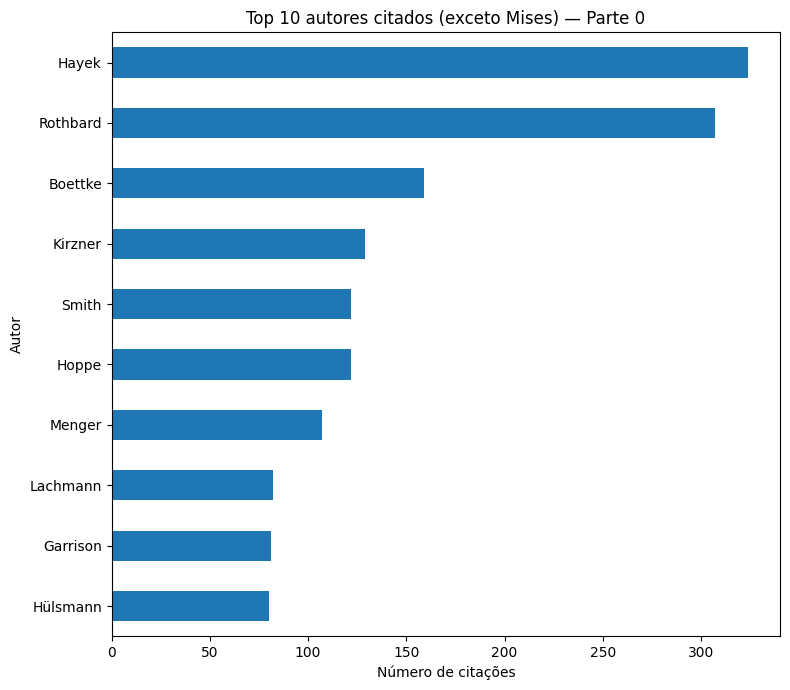

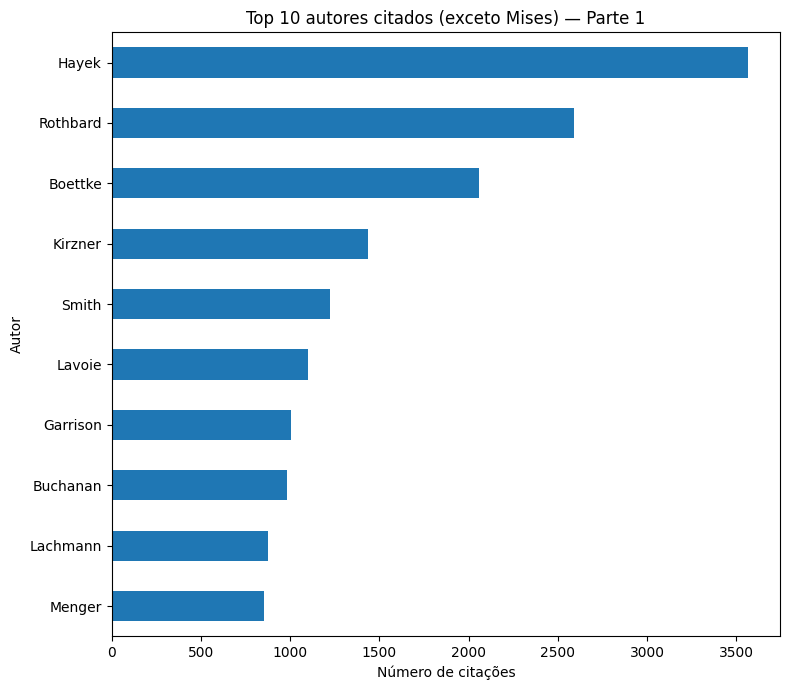

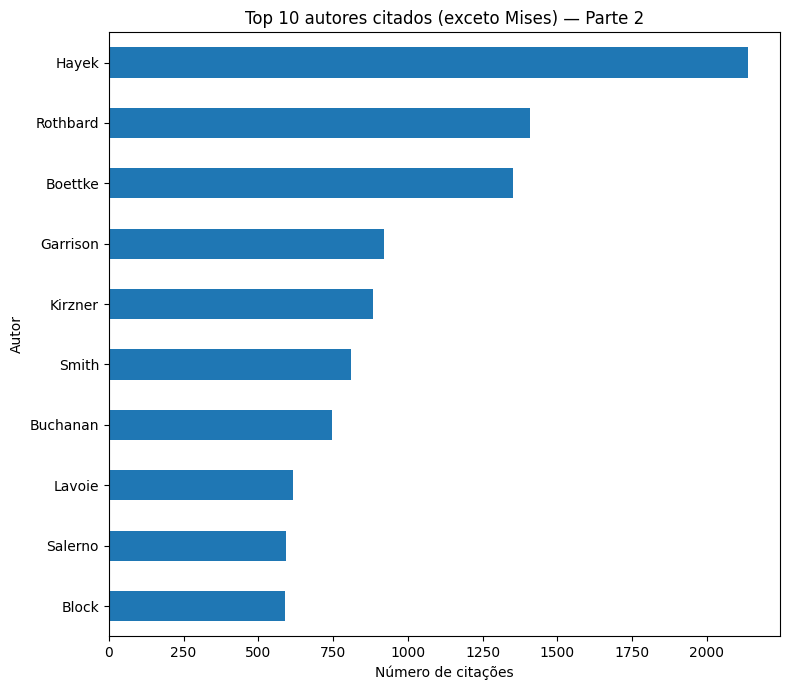

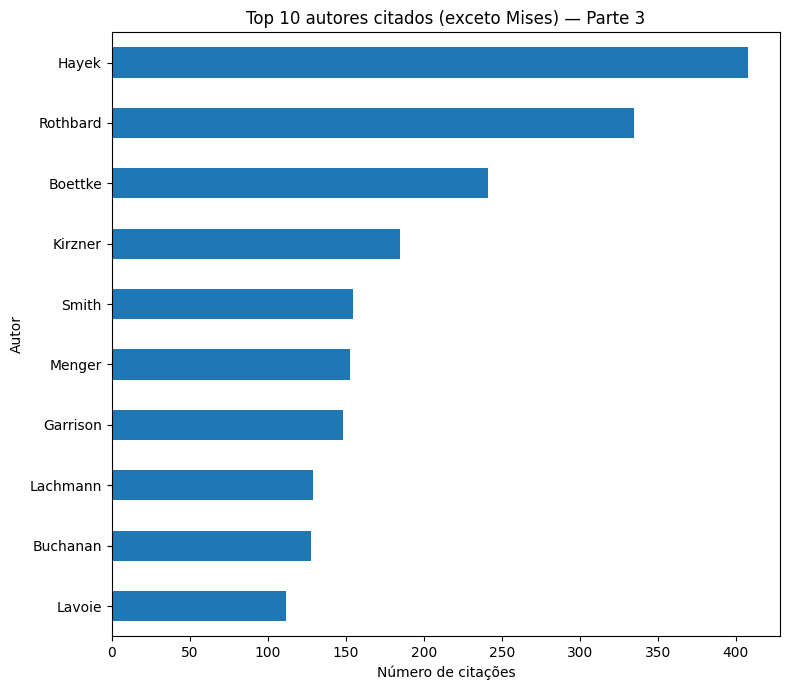

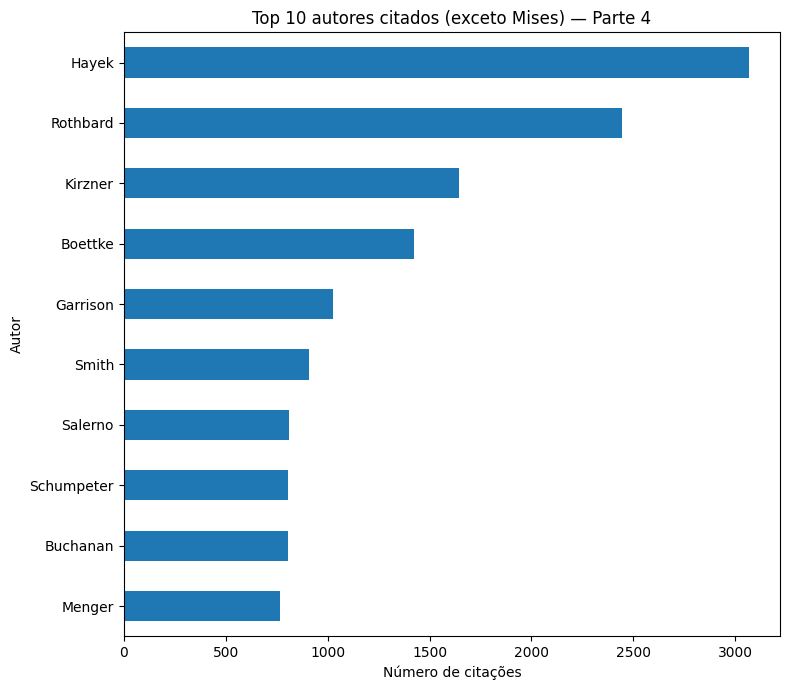

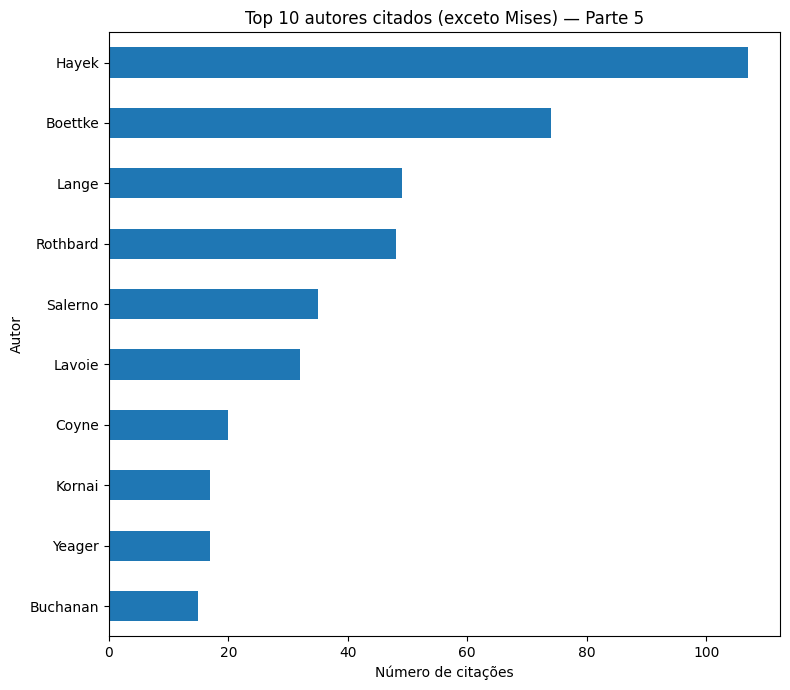

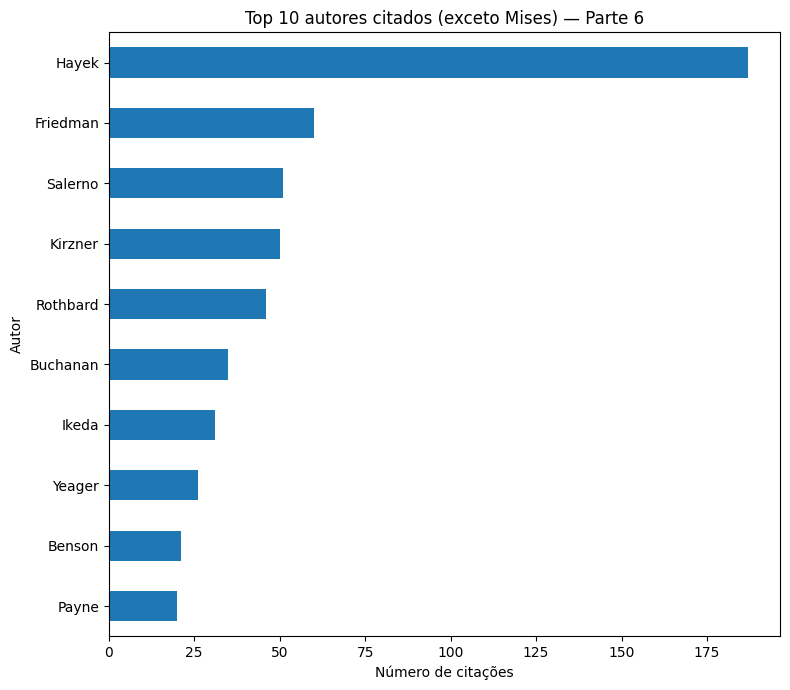

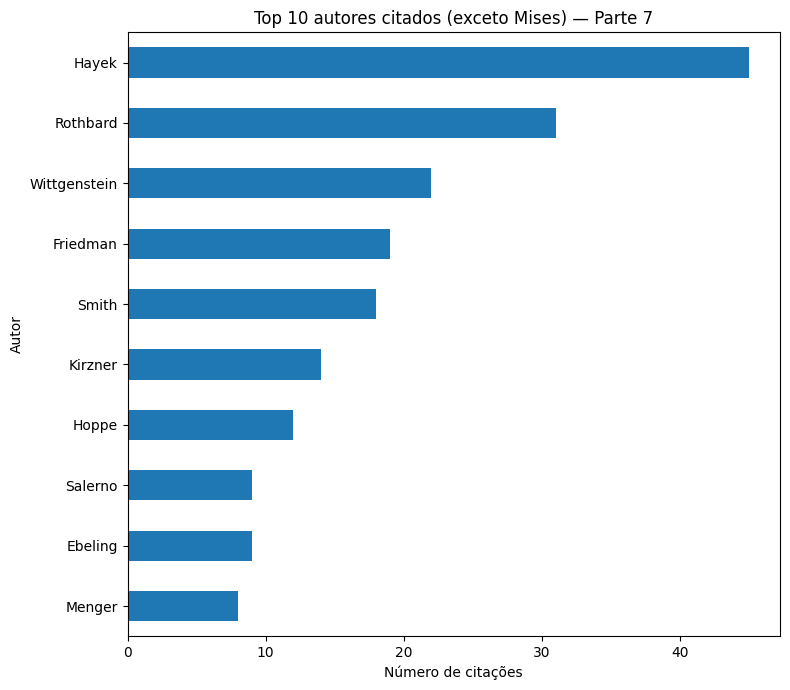

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

TOP_K = 10

df = pairs_df.dropna(subset=["human_action_part_number", "author_citation"])

# remove Mises
df = df[~df["author_citation"].str.lower().str.contains("mises")]

# garante que part é numérico
df["human_action_part_number"] = pd.to_numeric(
    df["human_action_part_number"], errors="coerce"
)

# remove parts inválidos
df = df.dropna(subset=["human_action_part_number"])

# ordenação numérica correta das parts
parts = sorted(df["human_action_part_number"].unique())

for part in parts:
    part_df = df[df["human_action_part_number"] == part]

    top_authors = (
        part_df["author_citation"]
        .value_counts()
        .head(TOP_K)
        .sort_values(ascending=True)
    )

    if top_authors.empty:
        continue

    plt.figure(figsize=(8, 4 + 0.3 * len(top_authors)))
    top_authors.plot(kind="barh")

    plt.title(f"Top {TOP_K} autores citados (exceto Mises) — Parte {int(part)}")
    plt.xlabel("Número de citações")
    plt.ylabel("Autor")

    plt.tight_layout()
    plt.show()


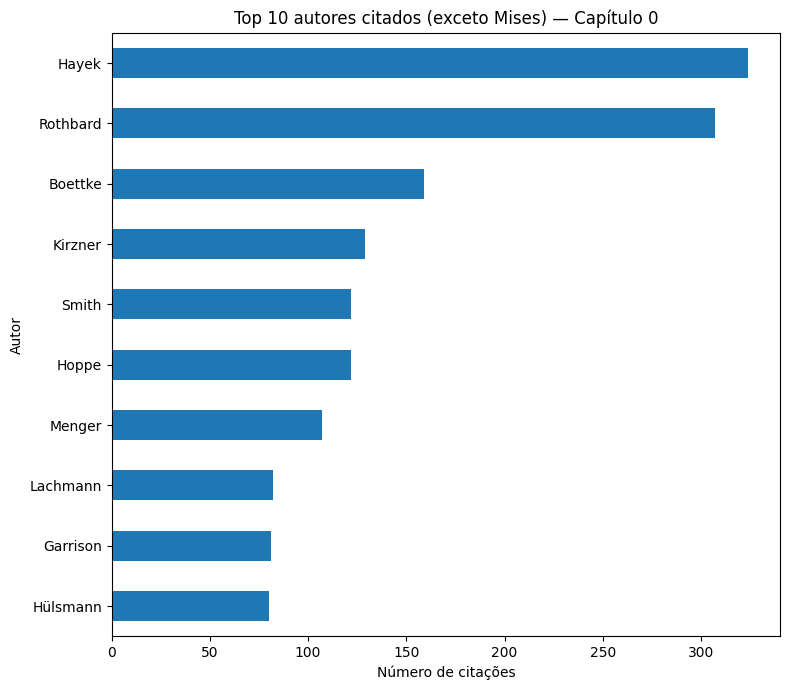

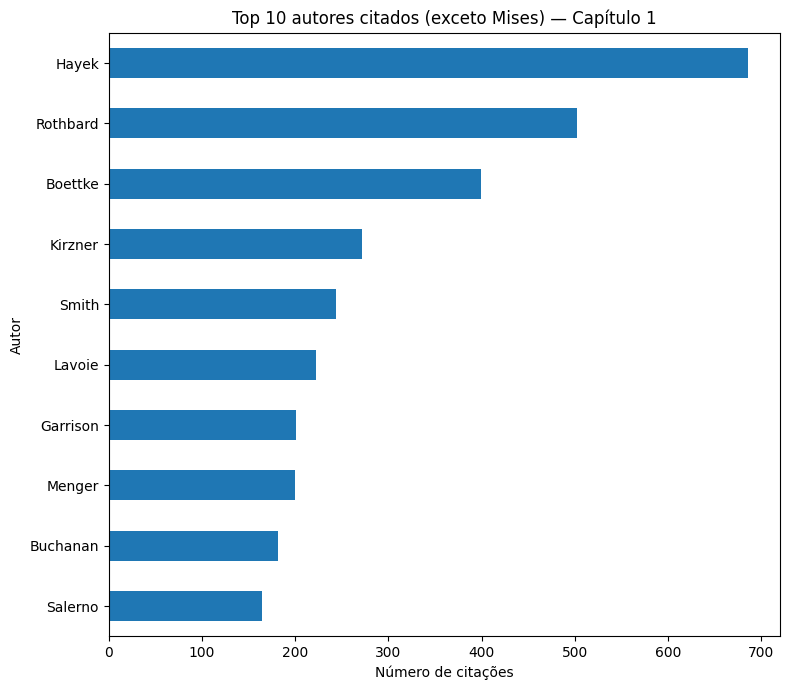

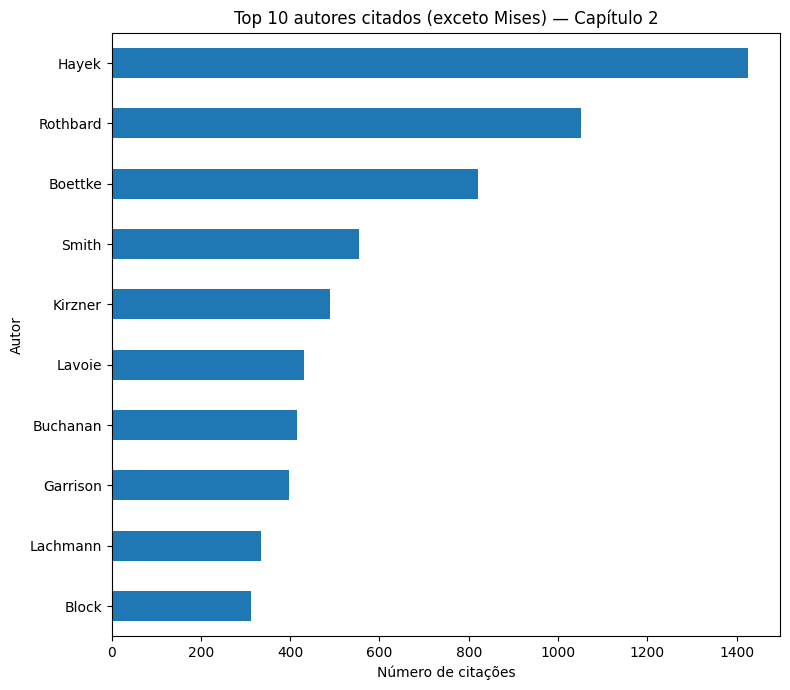

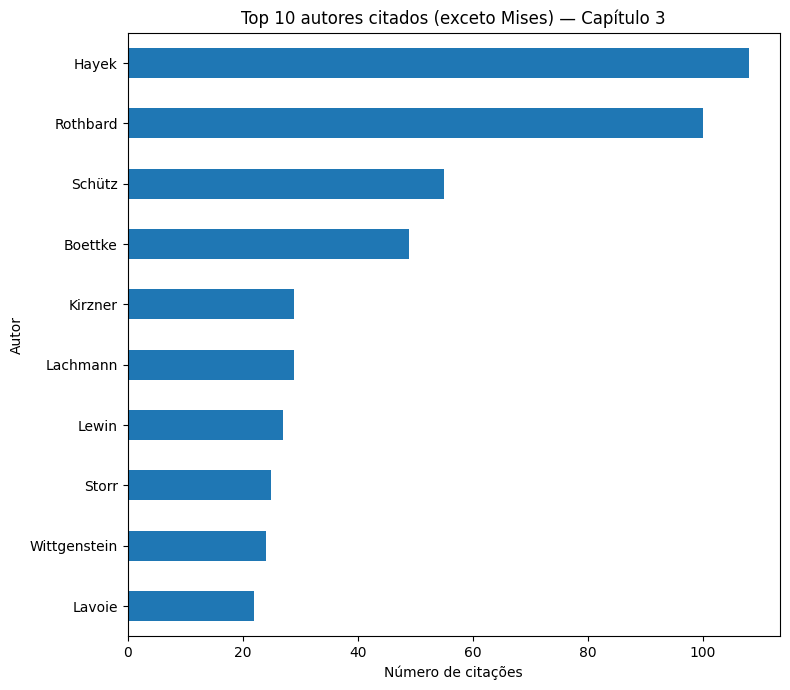

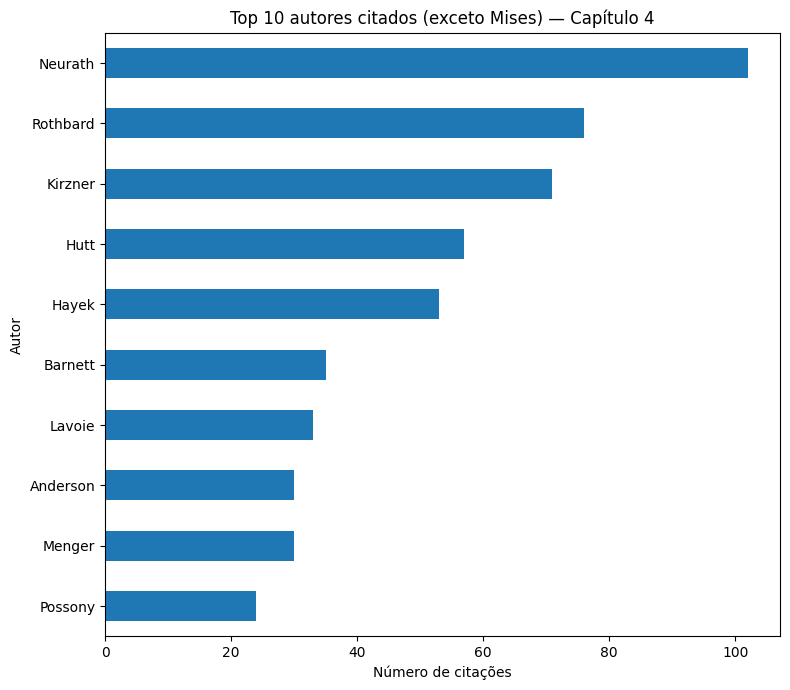

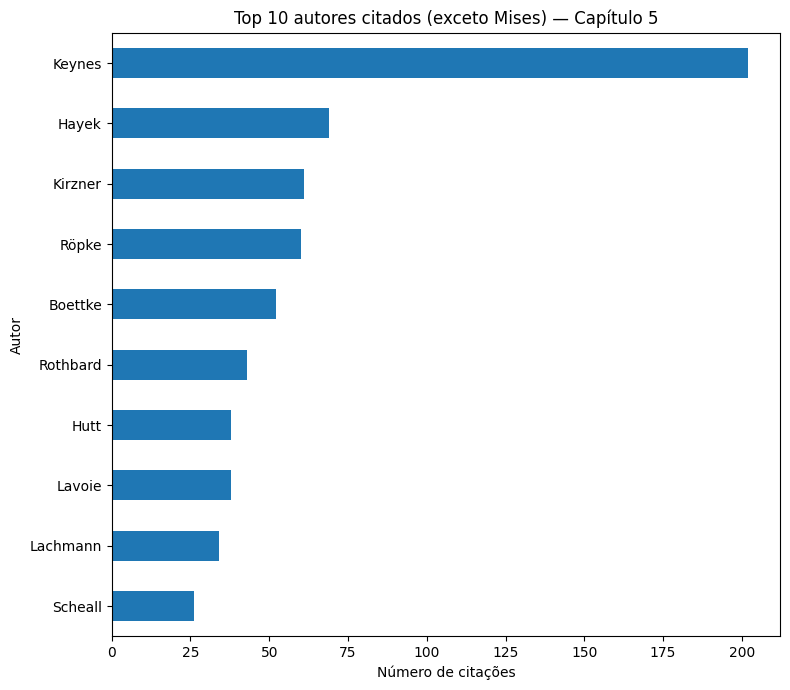

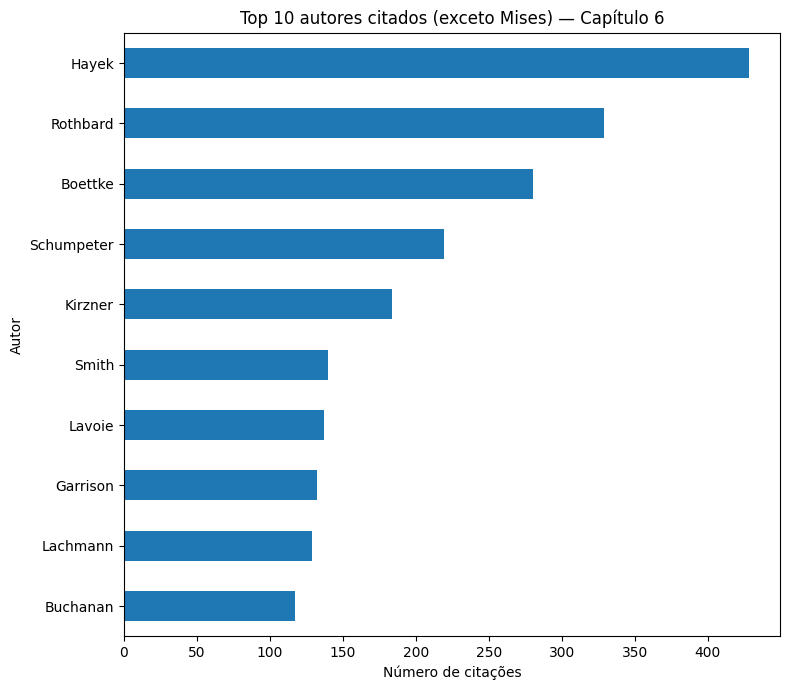

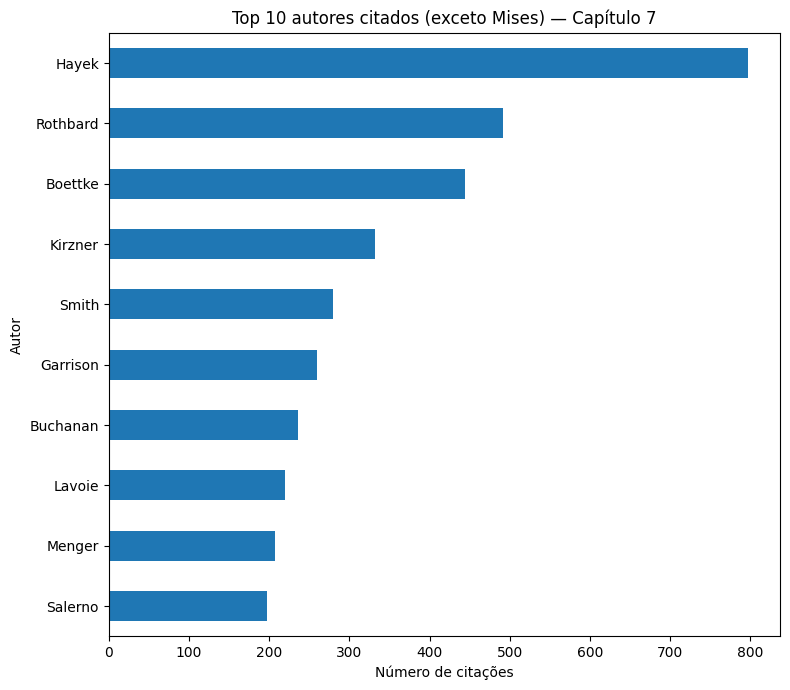

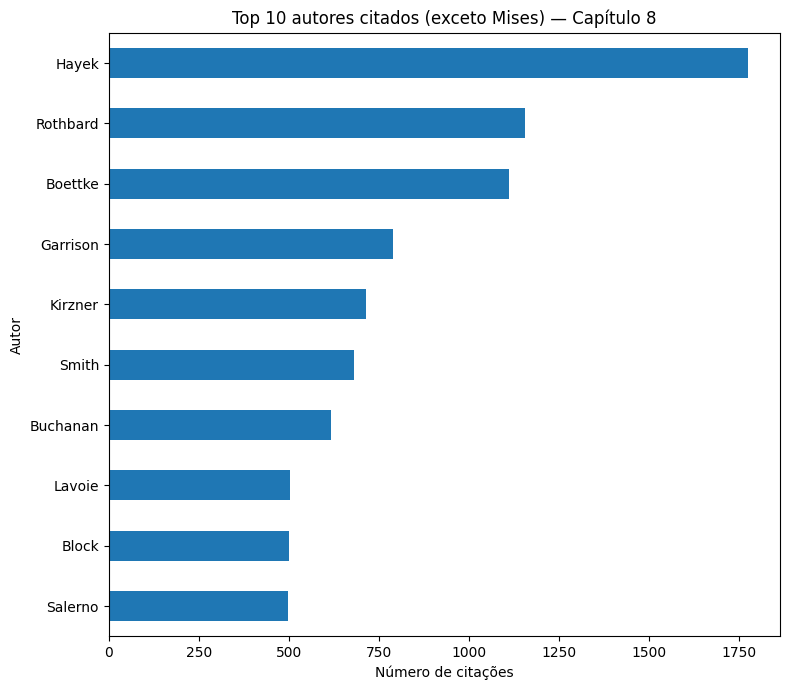

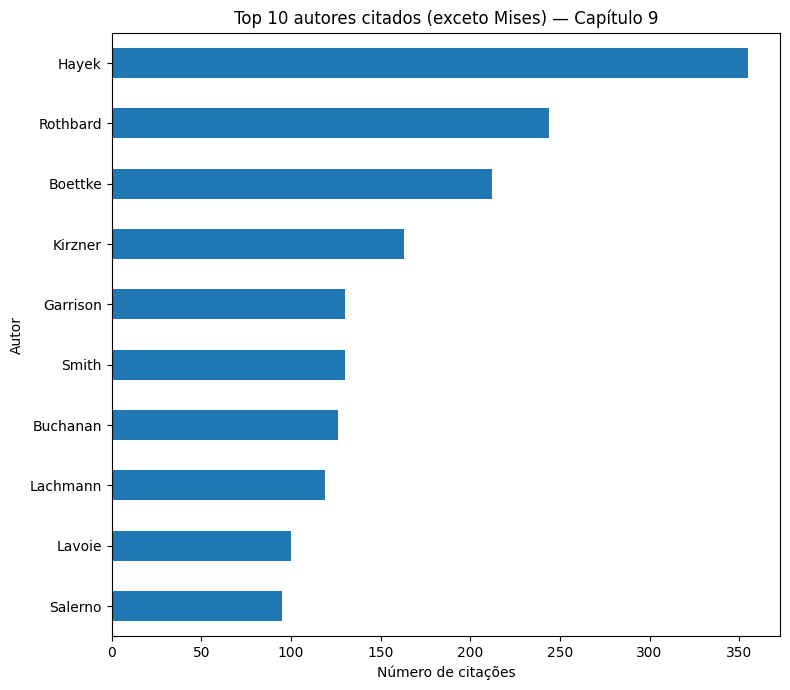

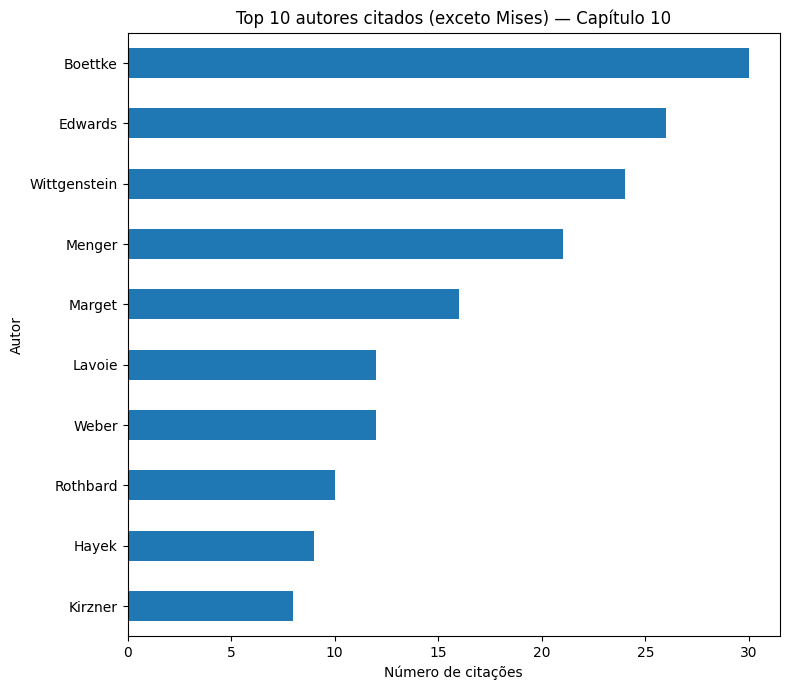

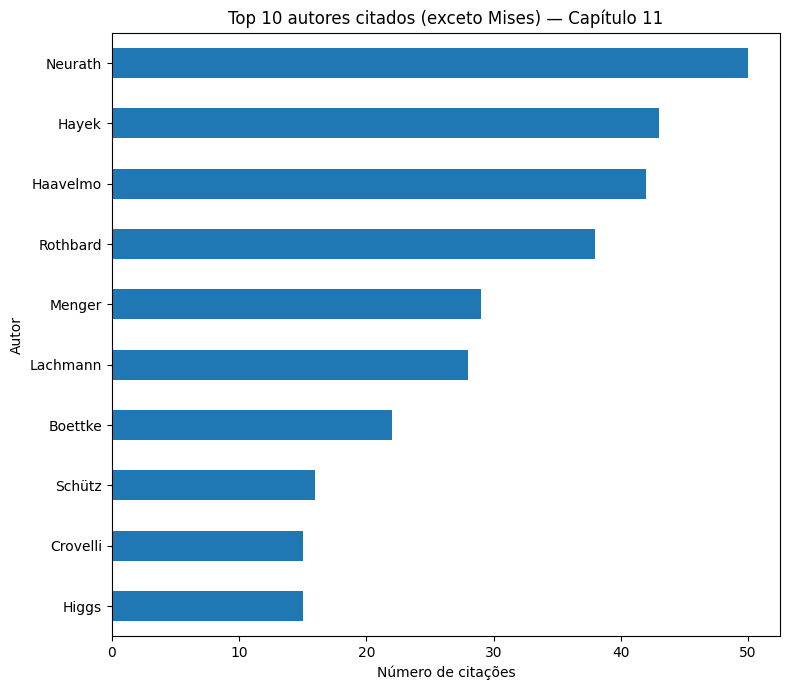

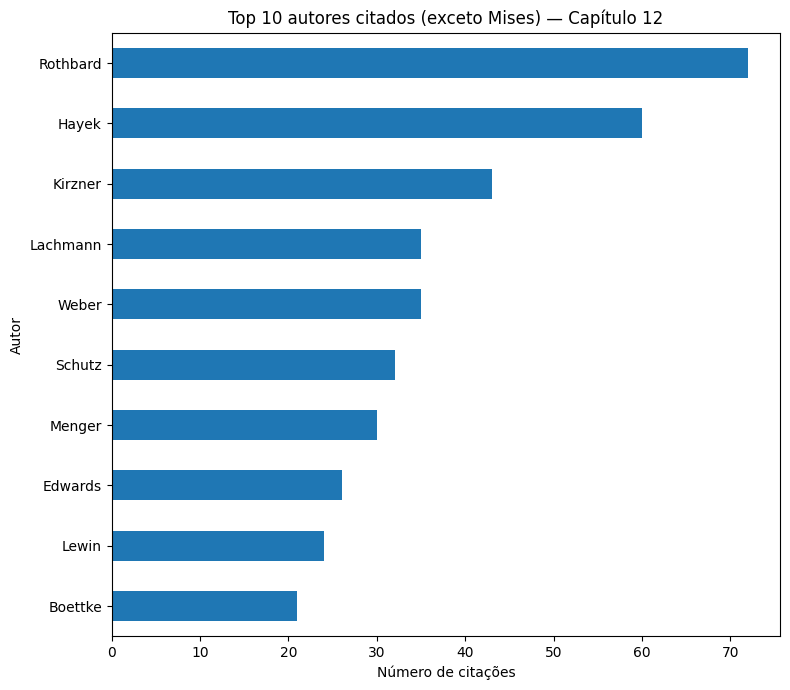

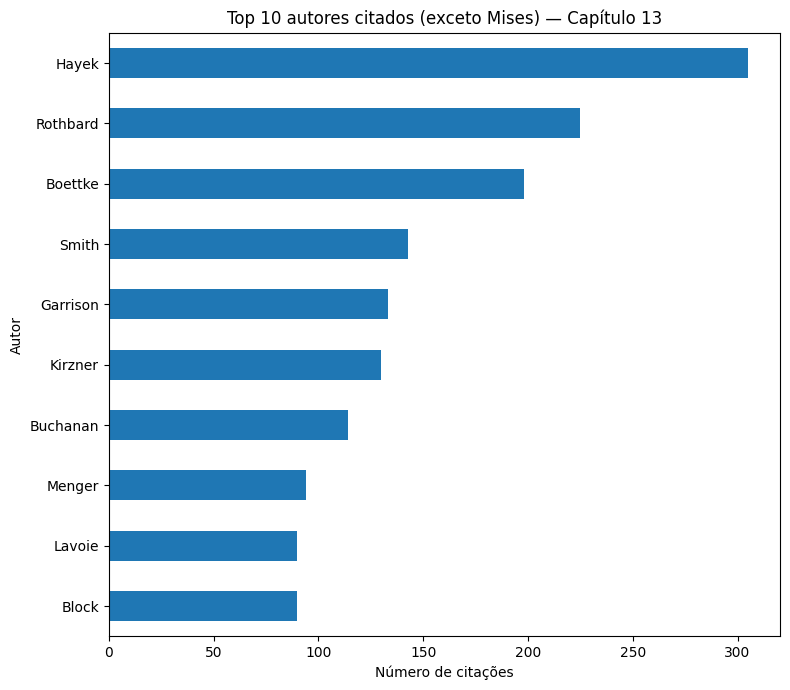

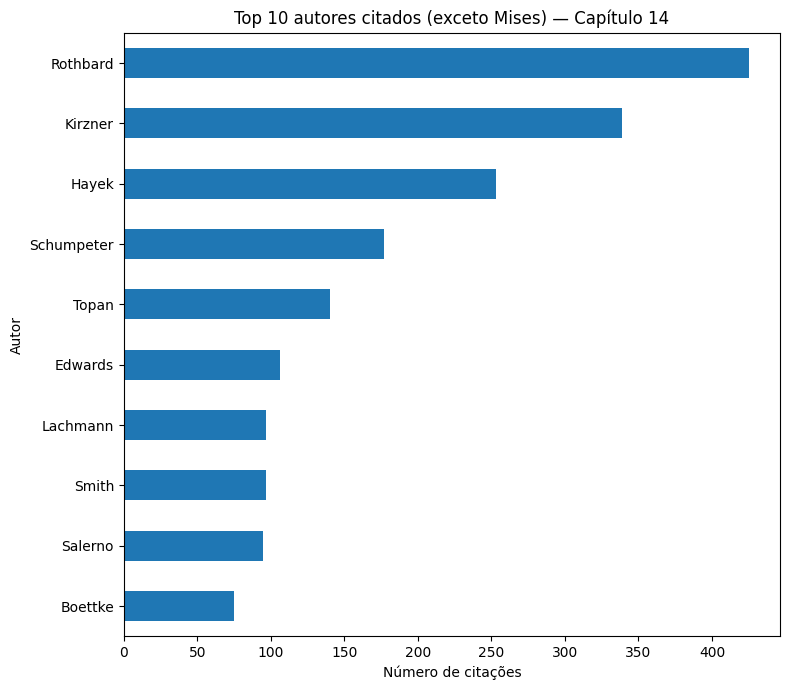

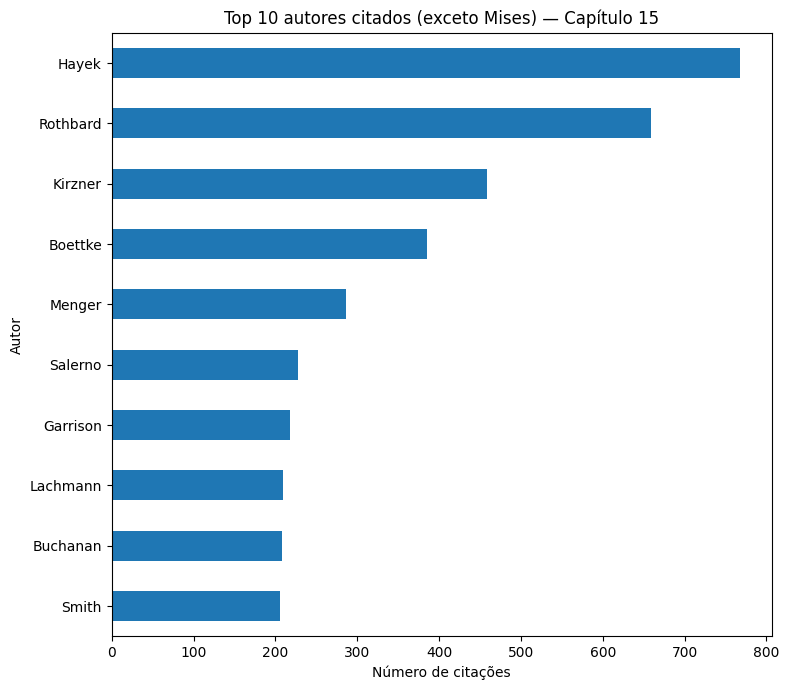

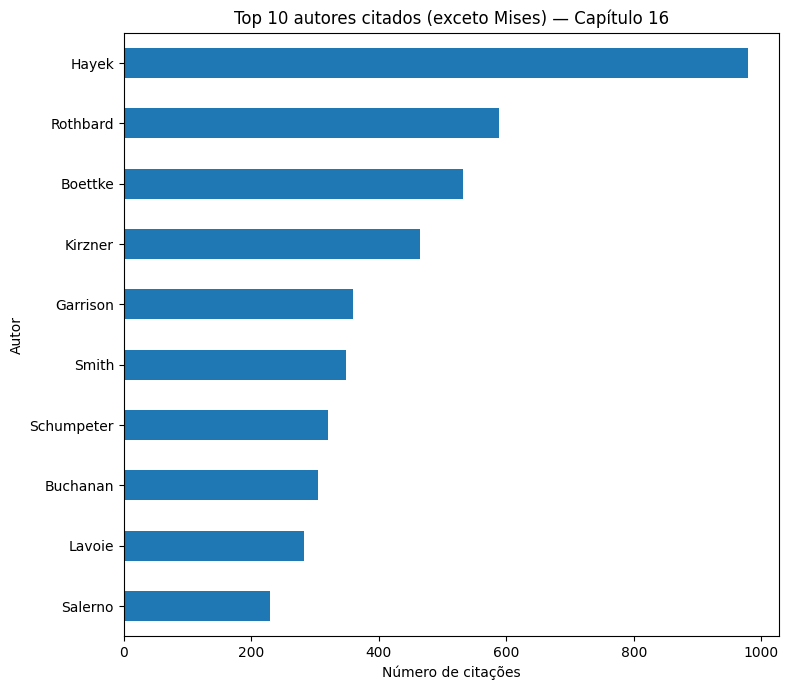

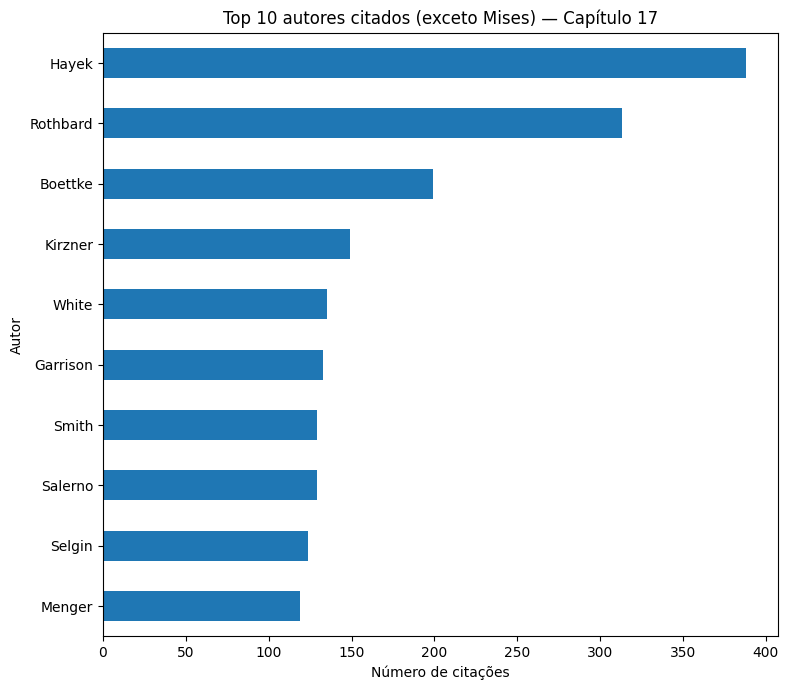

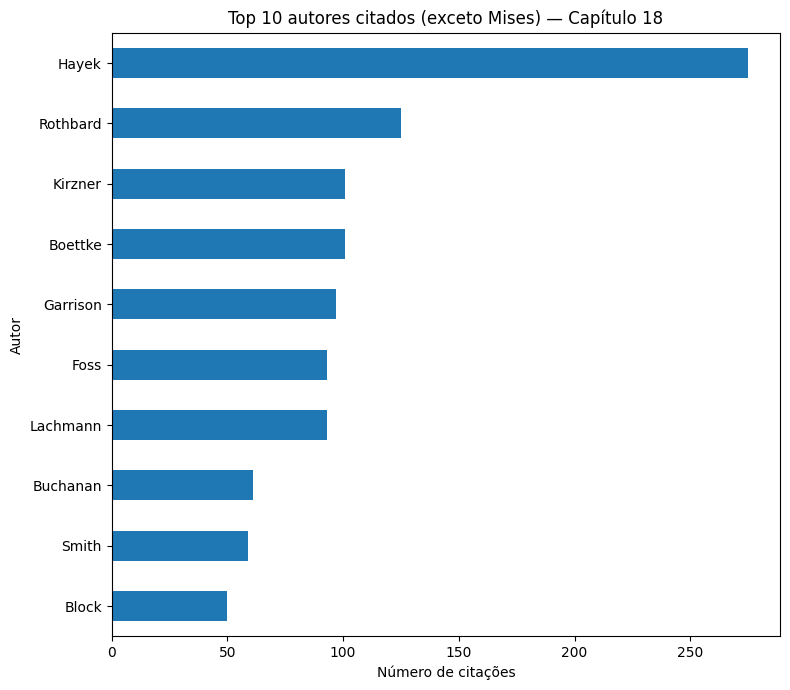

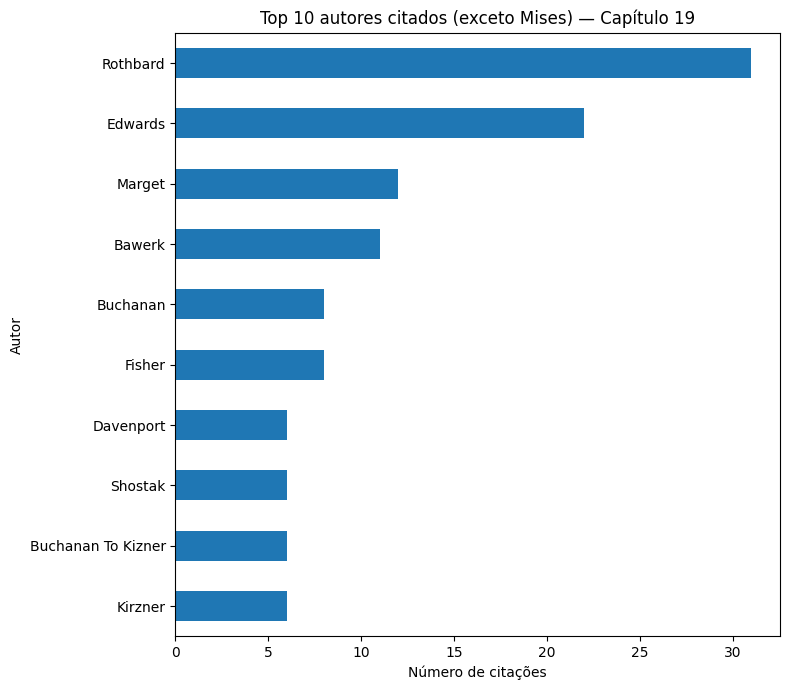

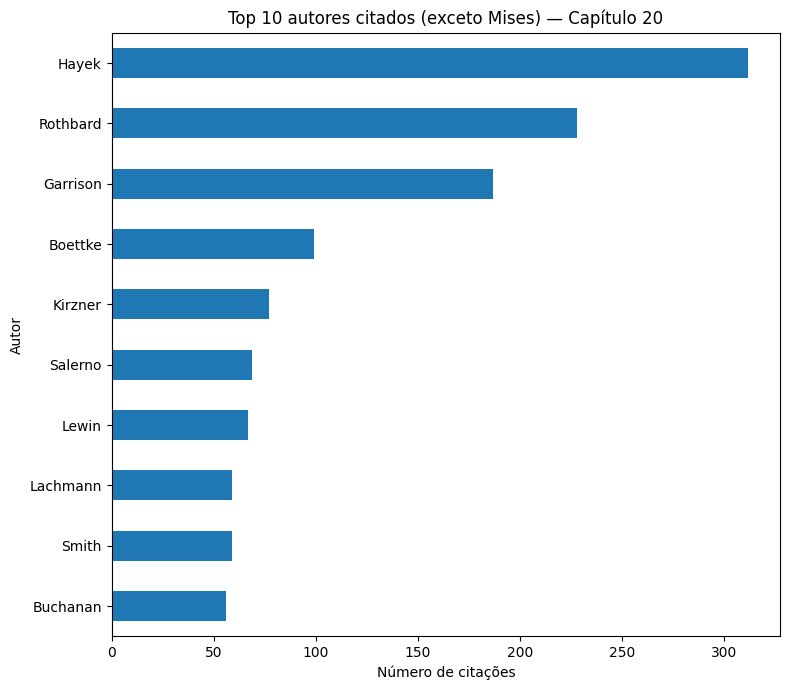

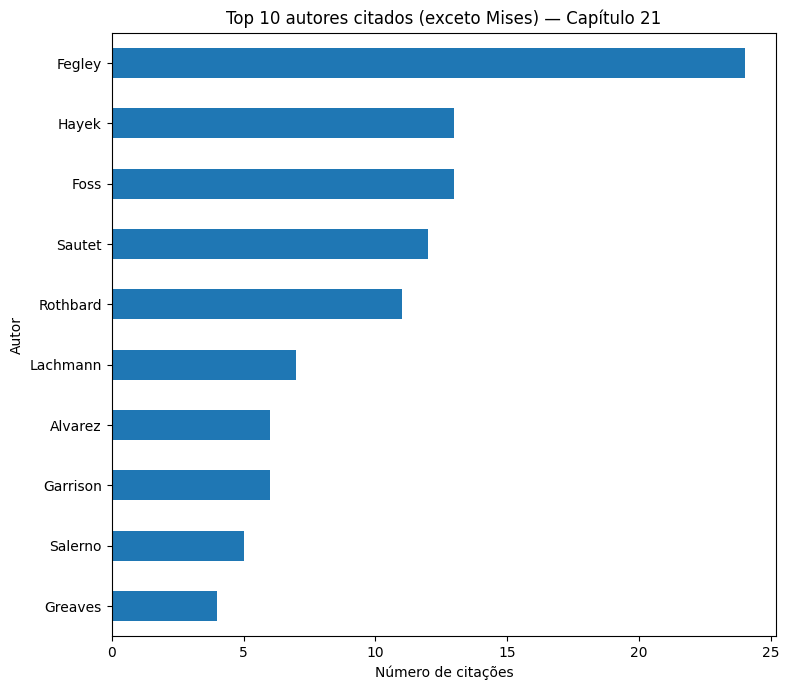

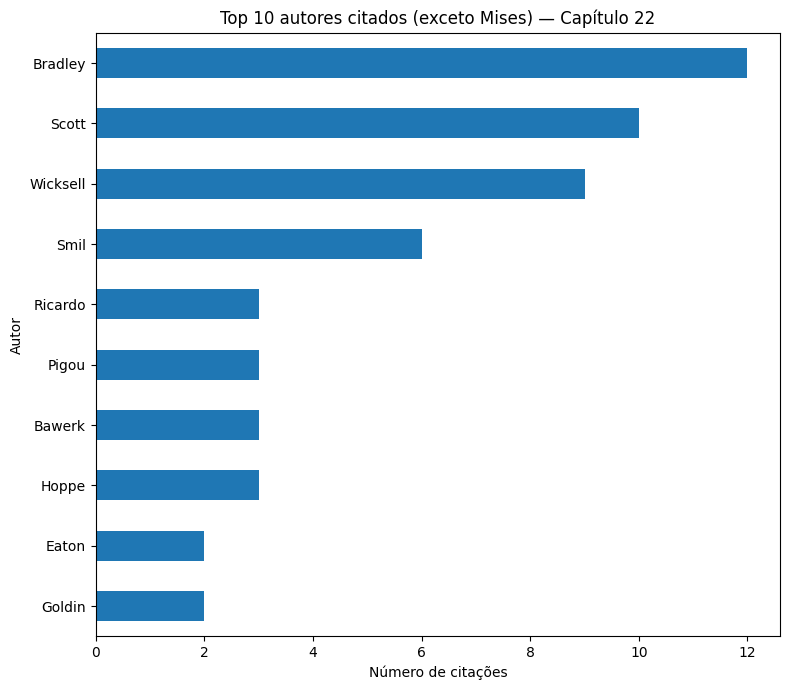

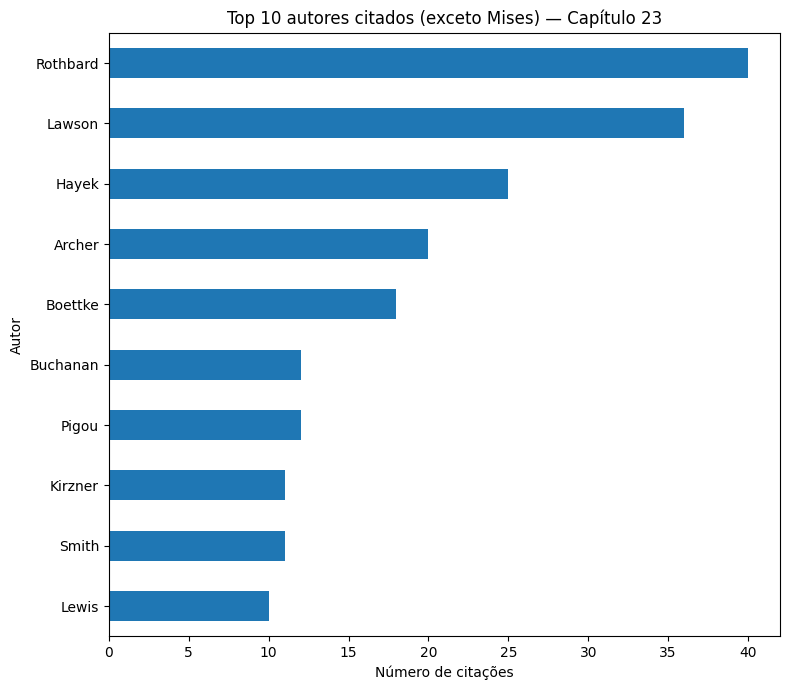

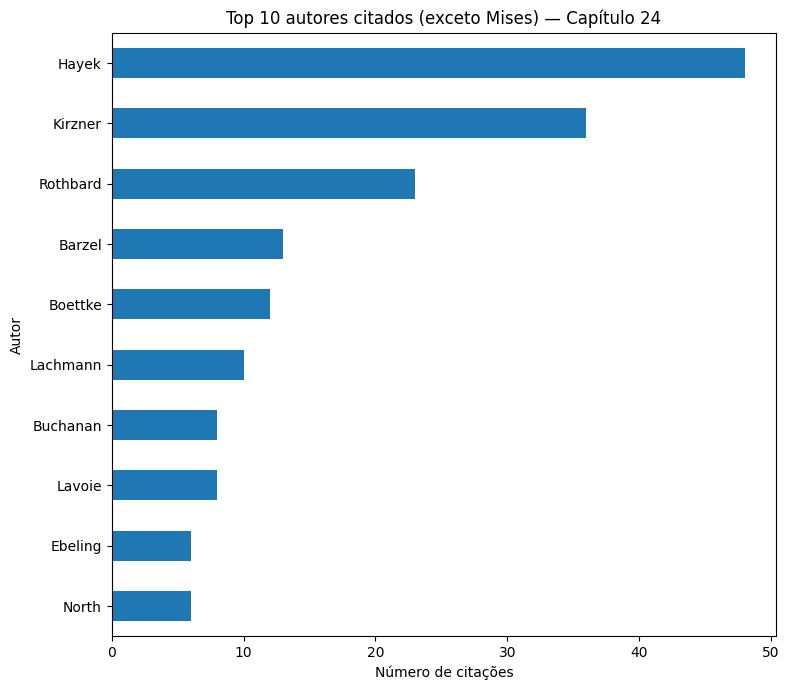

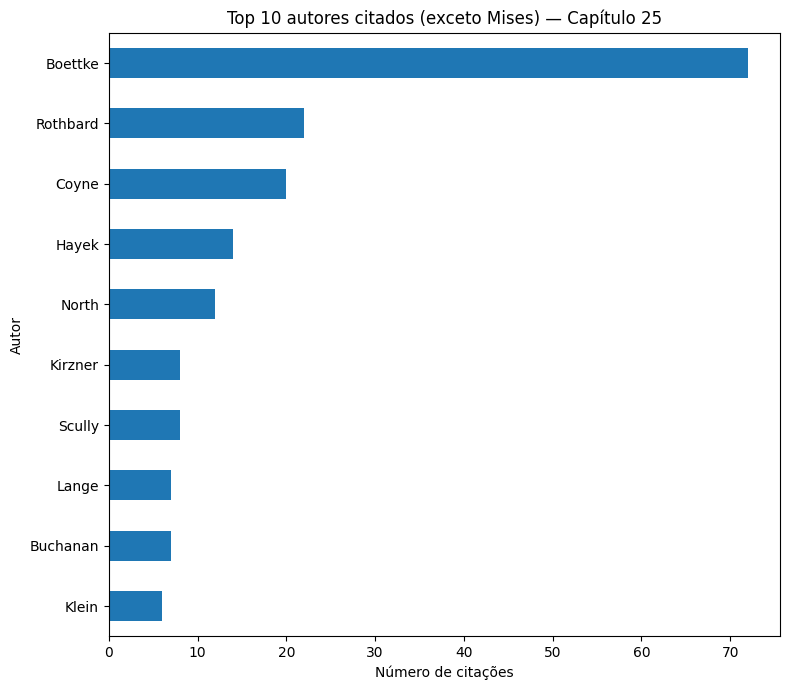

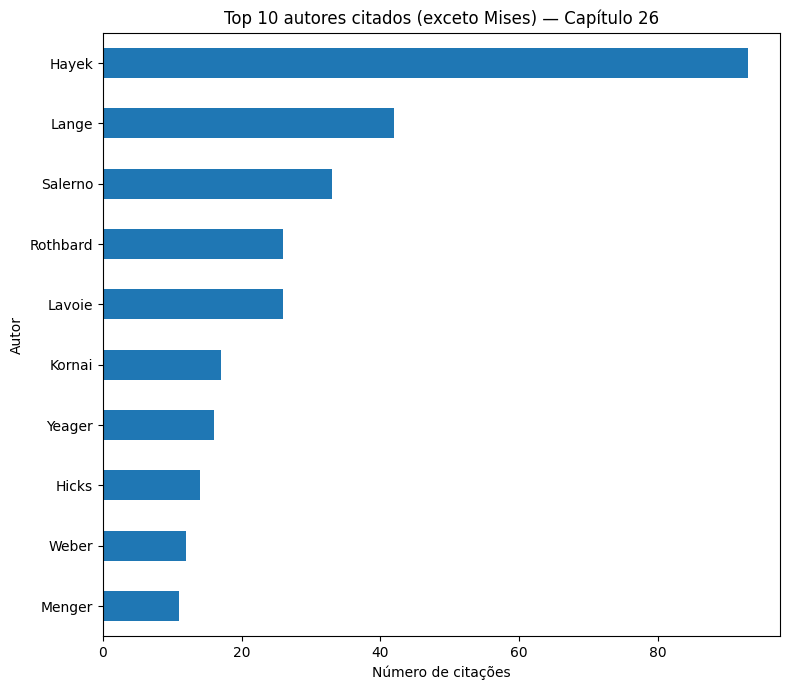

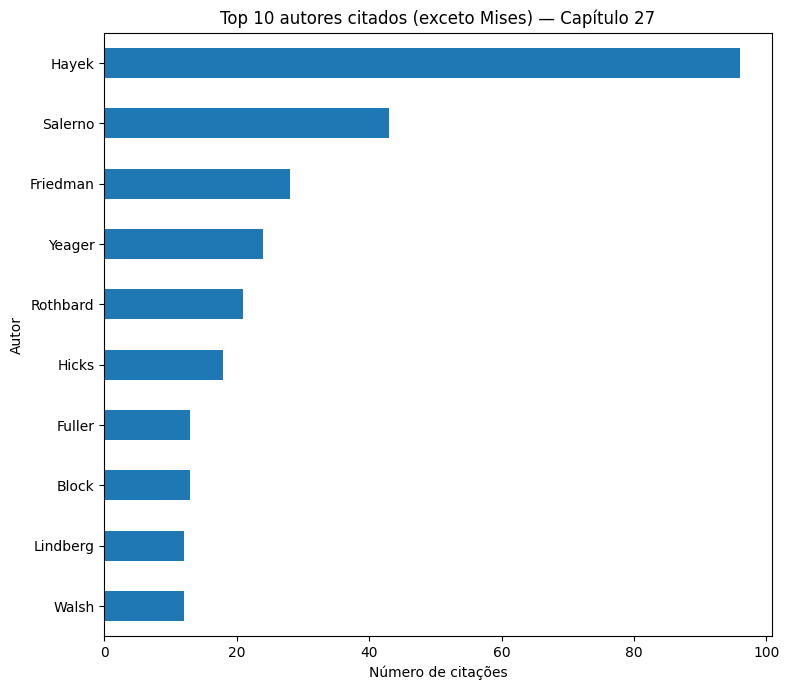

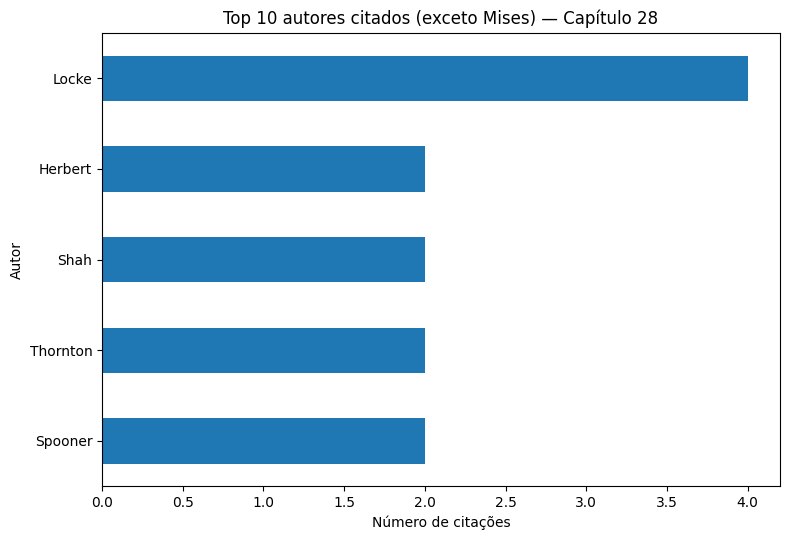

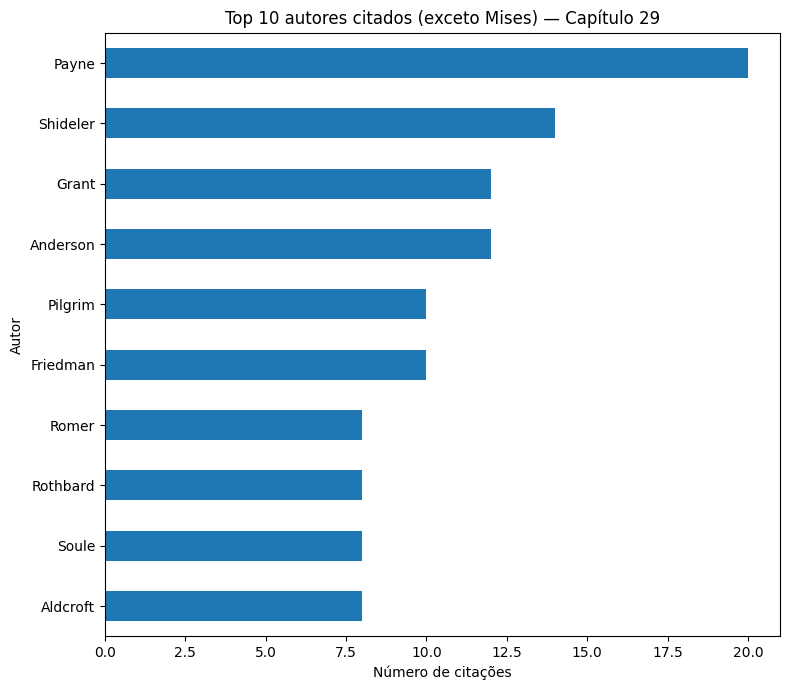

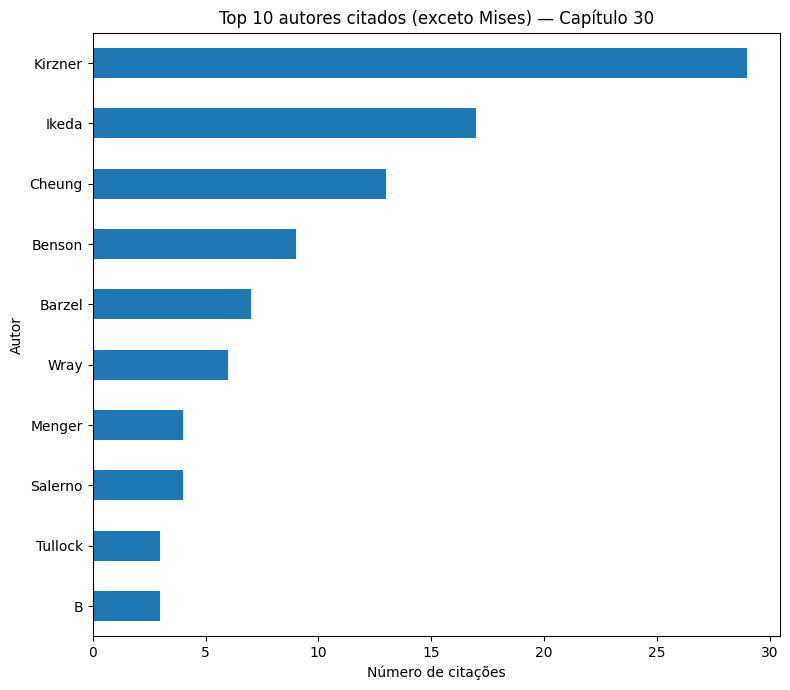

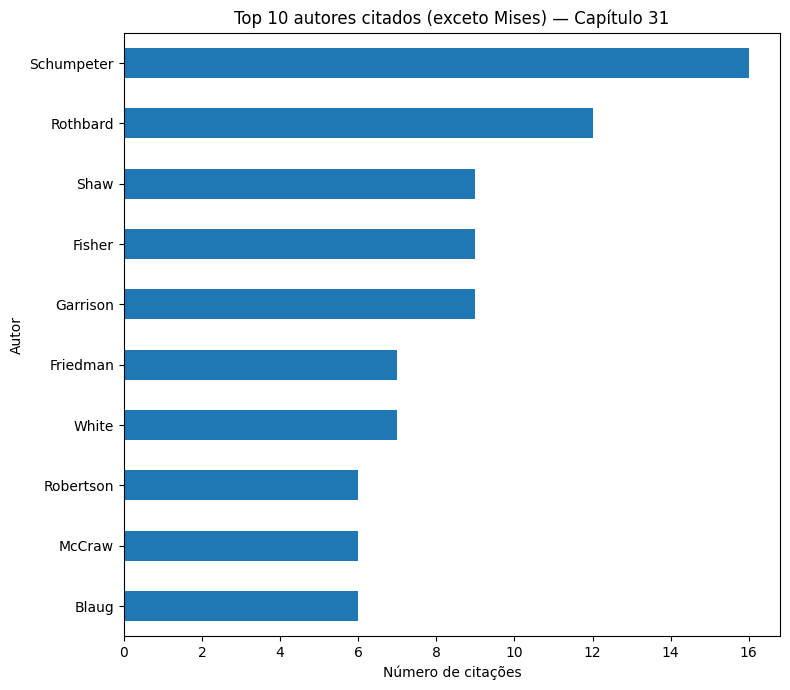

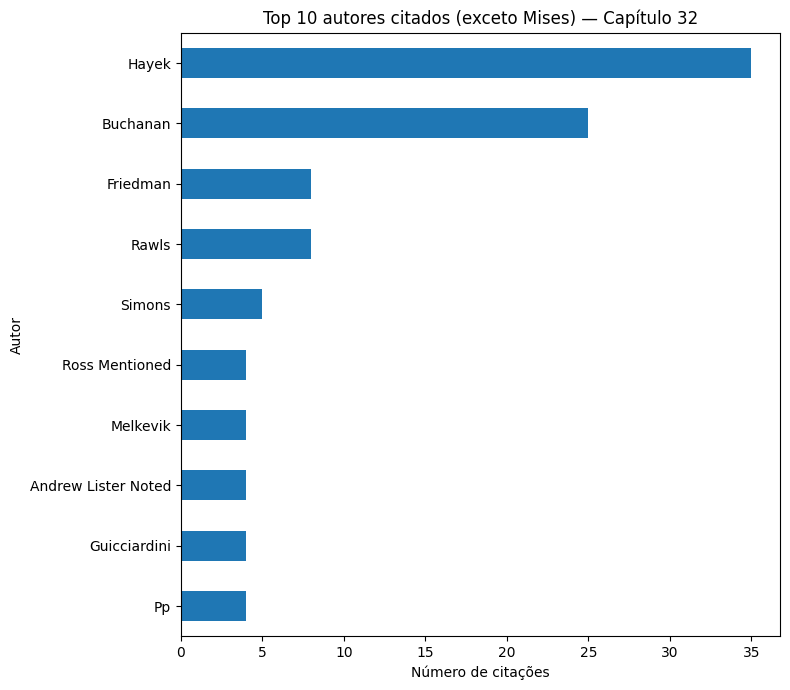

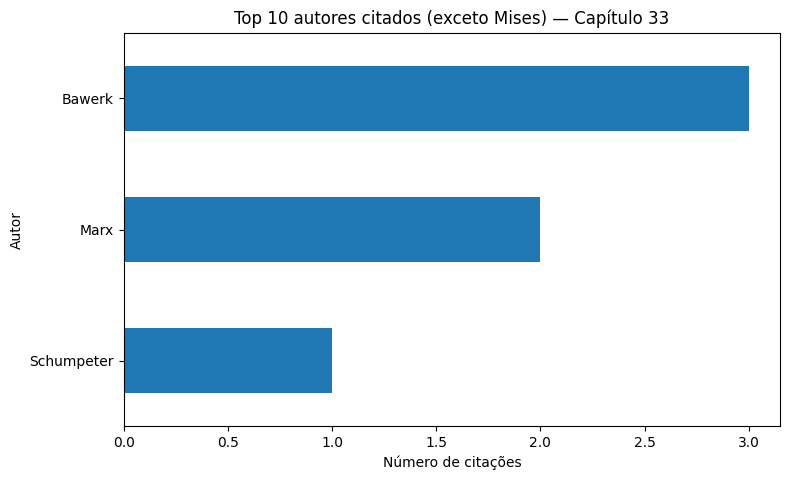

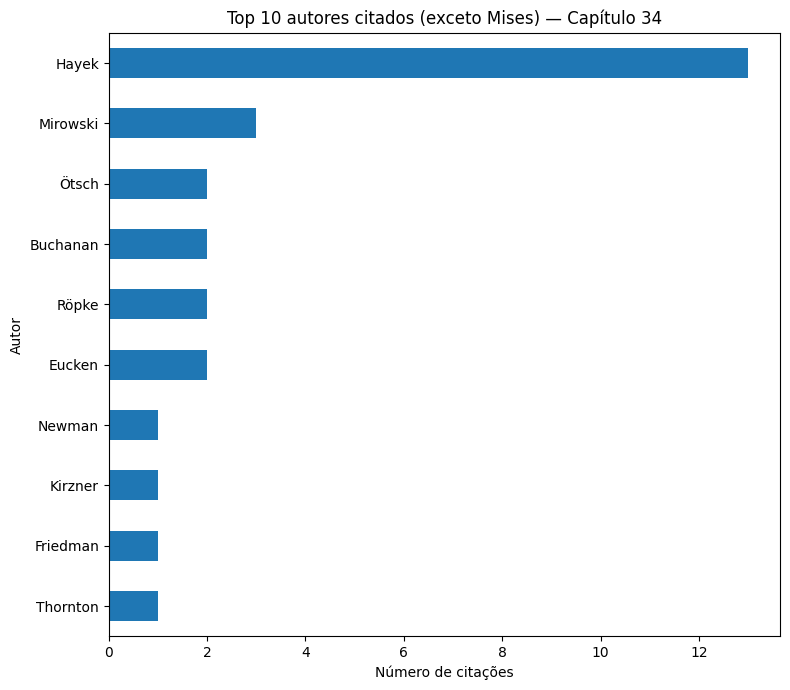

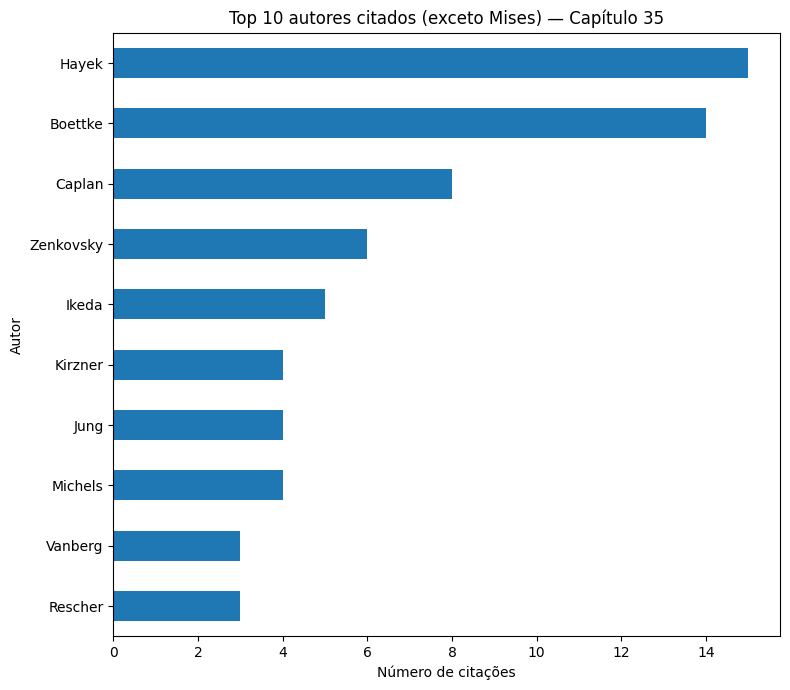

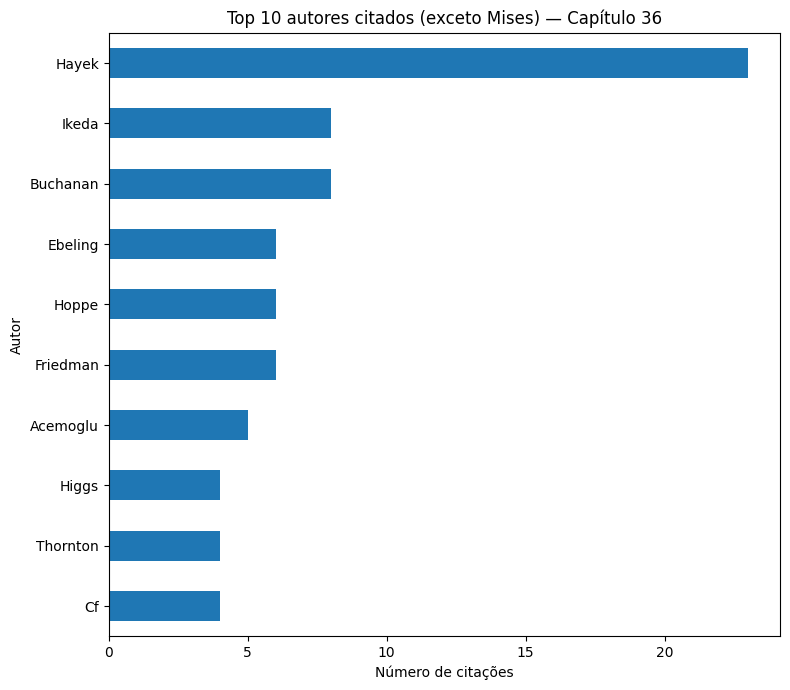

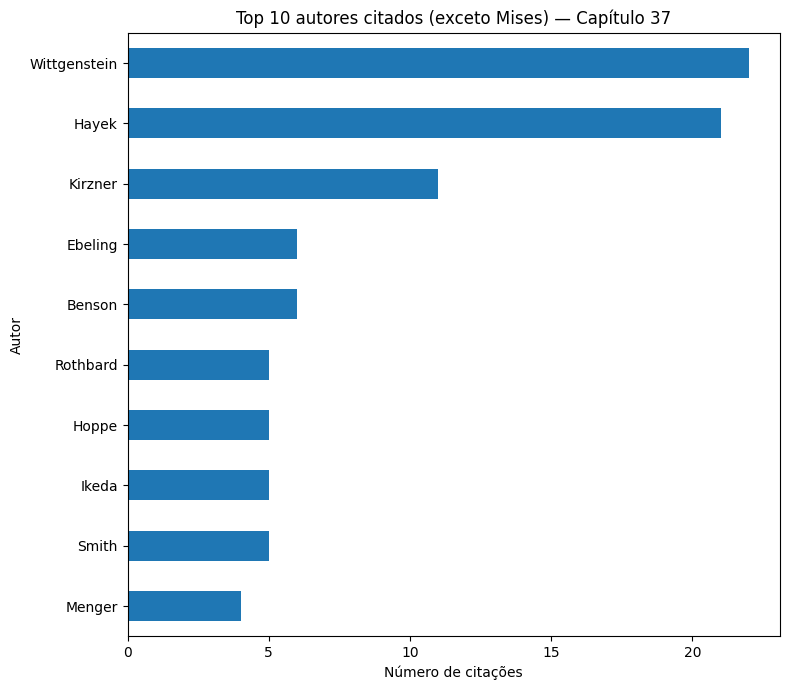

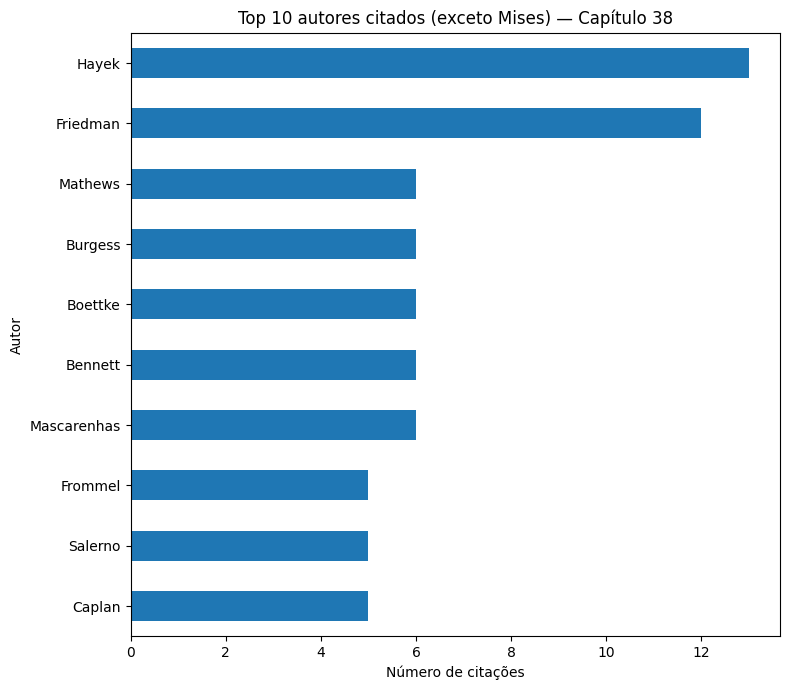

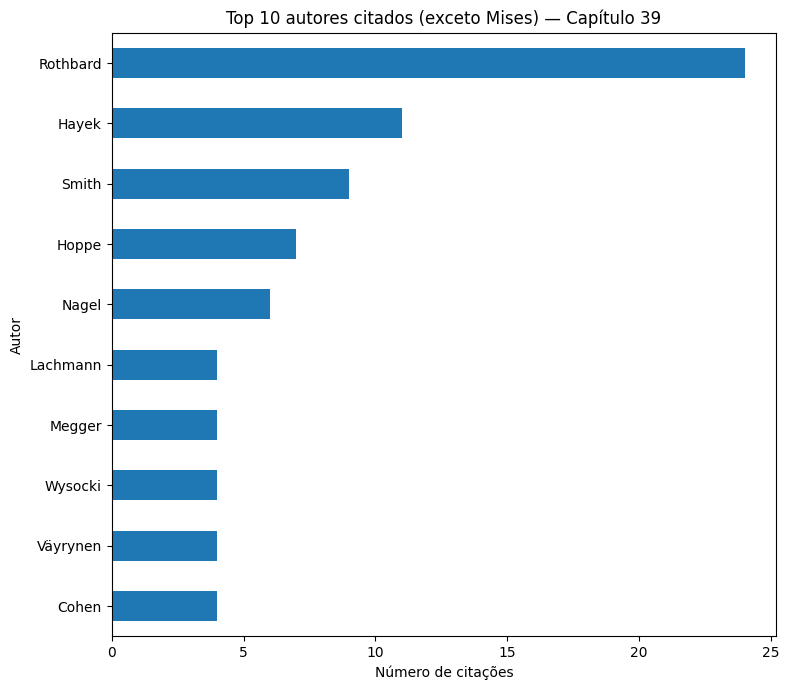

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

TOP_K = 10

df = pairs_df.dropna(subset=["human_action_chapter_number", "author_citation"])

# remove Mises
df = df[~df["author_citation"].str.lower().str.contains("mises")]

# garante que capítulo é numérico
df["human_action_chapter_number"] = pd.to_numeric(
    df["human_action_chapter_number"], errors="coerce"
)

# remove capítulos inválidos (se houver)
df = df.dropna(subset=["human_action_chapter_number"])

# ordenação numérica correta
chapters = sorted(df["human_action_chapter_number"].unique())

for chapter in chapters:
    chapter_df = df[df["human_action_chapter_number"] == chapter]

    top_authors = (
        chapter_df["author_citation"]
        .value_counts()
        .head(TOP_K)
        .sort_values(ascending=True)
    )

    if top_authors.empty:
        continue

    plt.figure(figsize=(8, 4 + 0.3 * len(top_authors)))
    top_authors.plot(kind="barh")

    plt.title(
        f"Top {TOP_K} autores citados (exceto Mises) — Capítulo {int(chapter)}"
    )
    plt.xlabel("Número de citações")
    plt.ylabel("Autor")

    plt.tight_layout()
    plt.show()


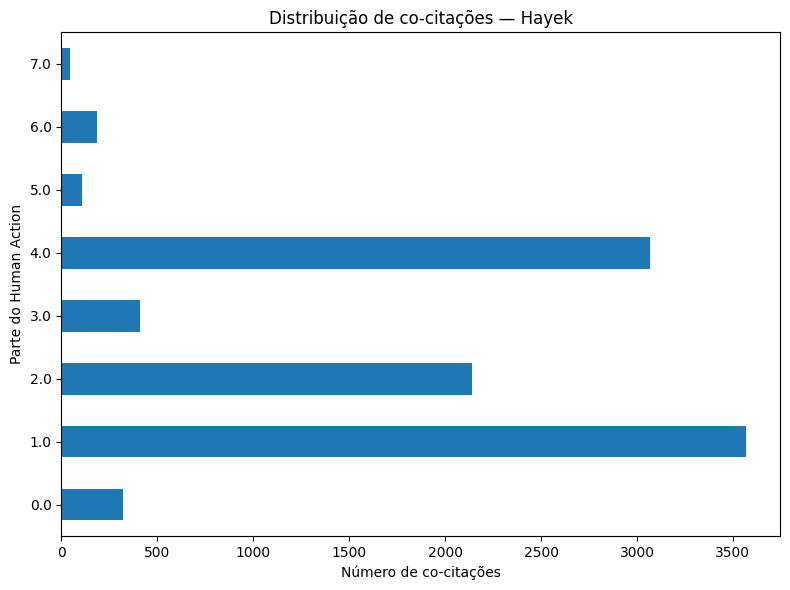

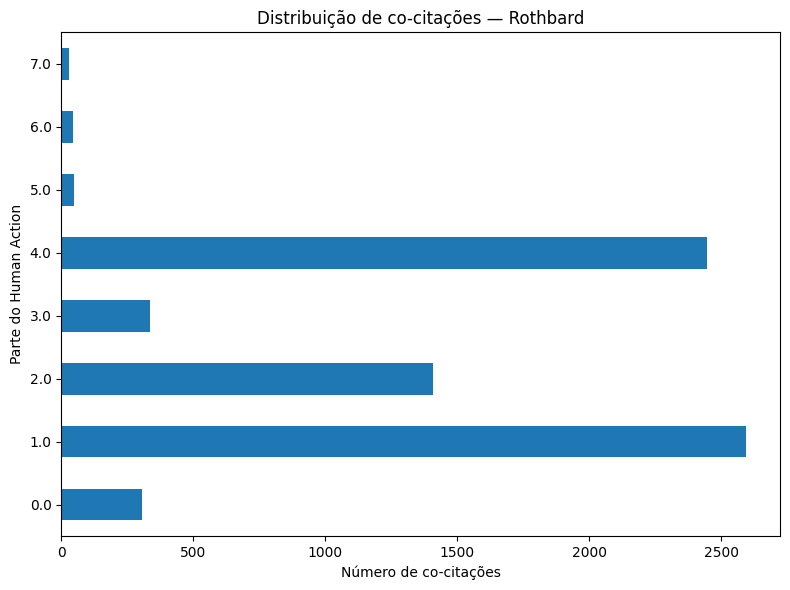

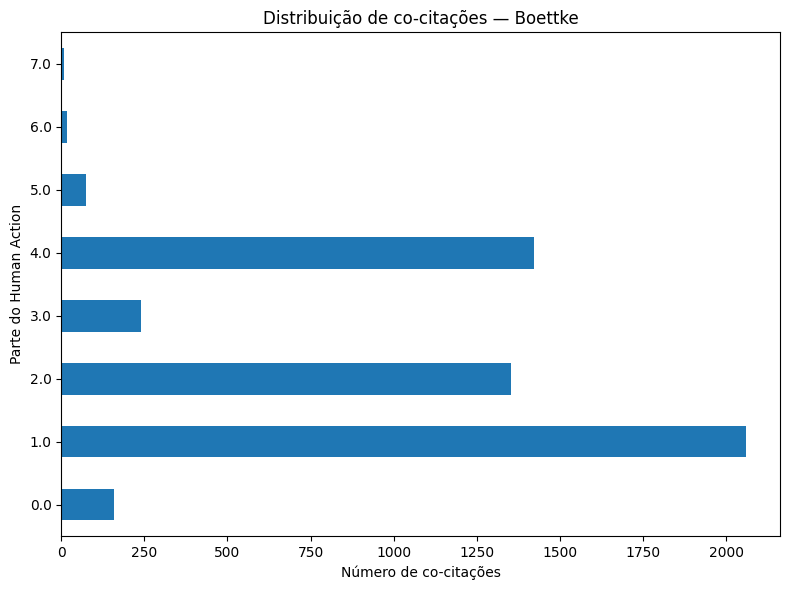

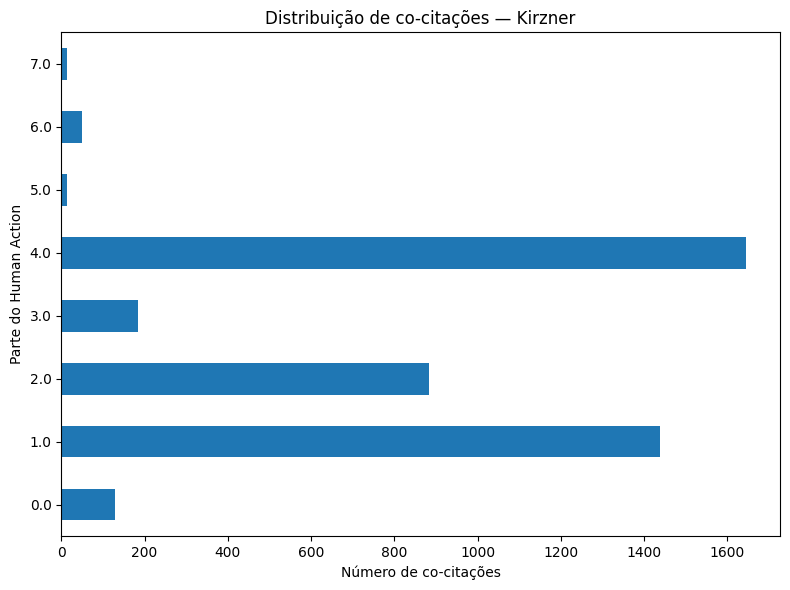

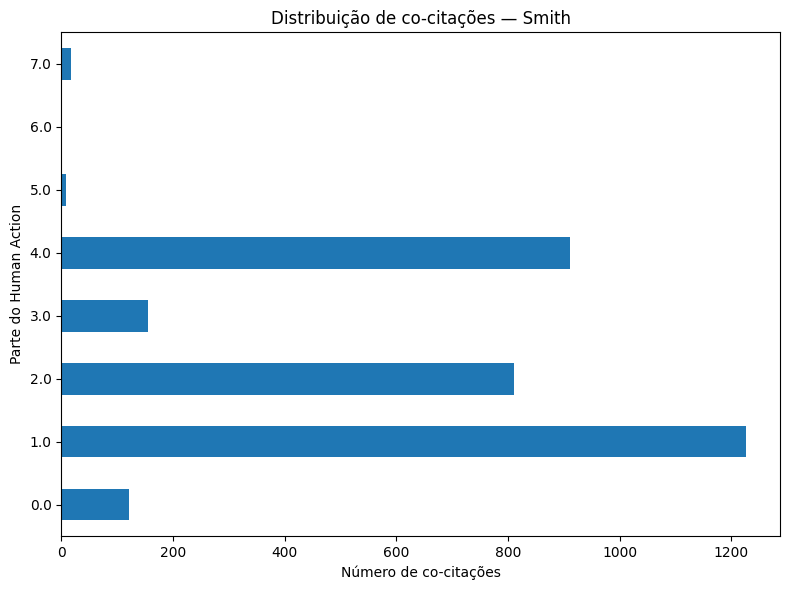

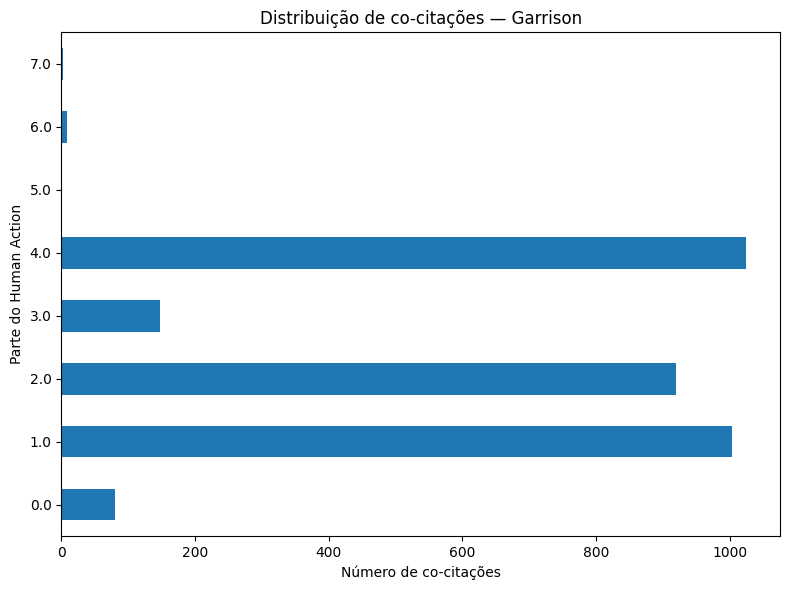

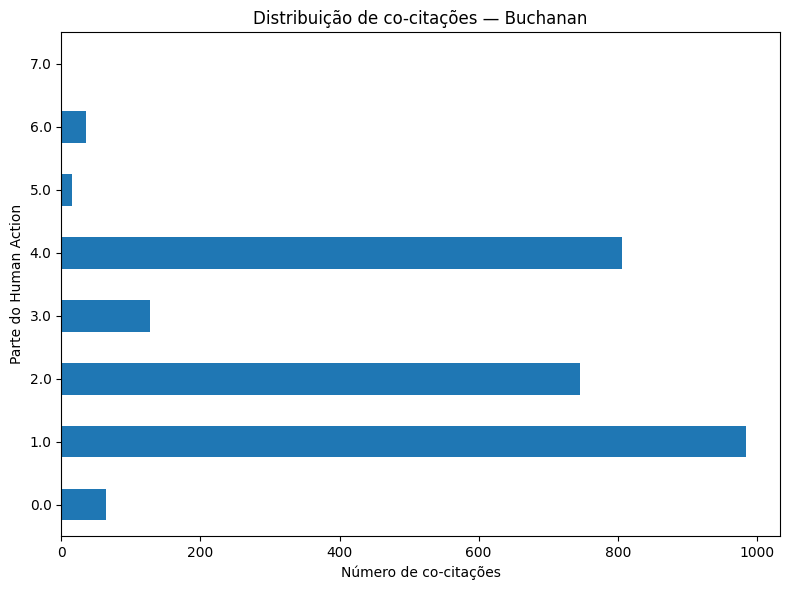

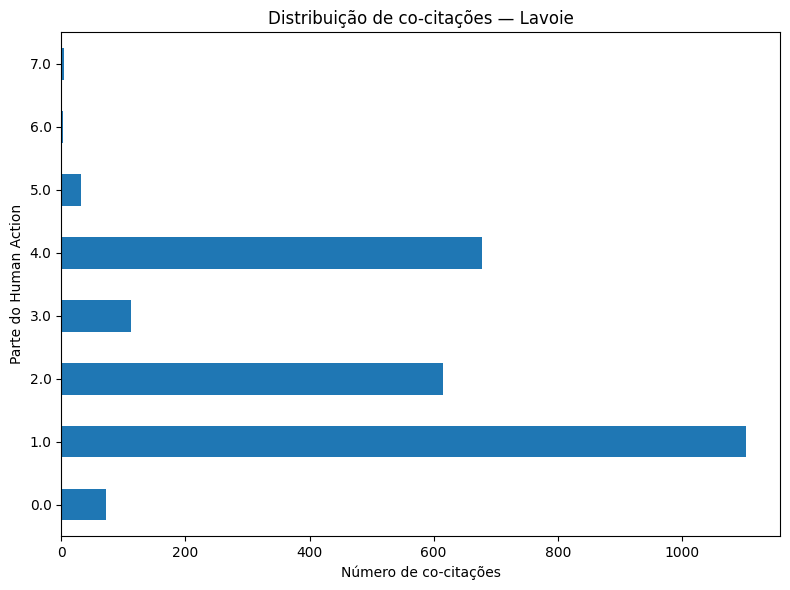

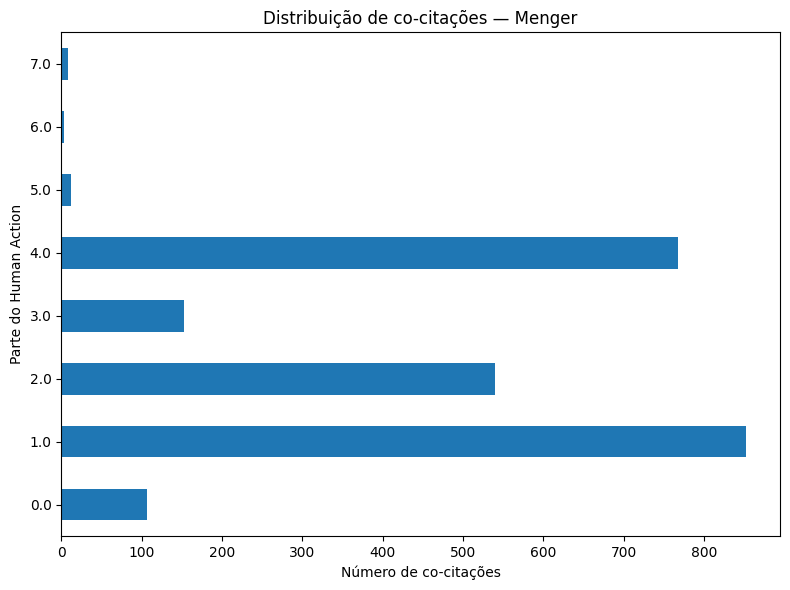

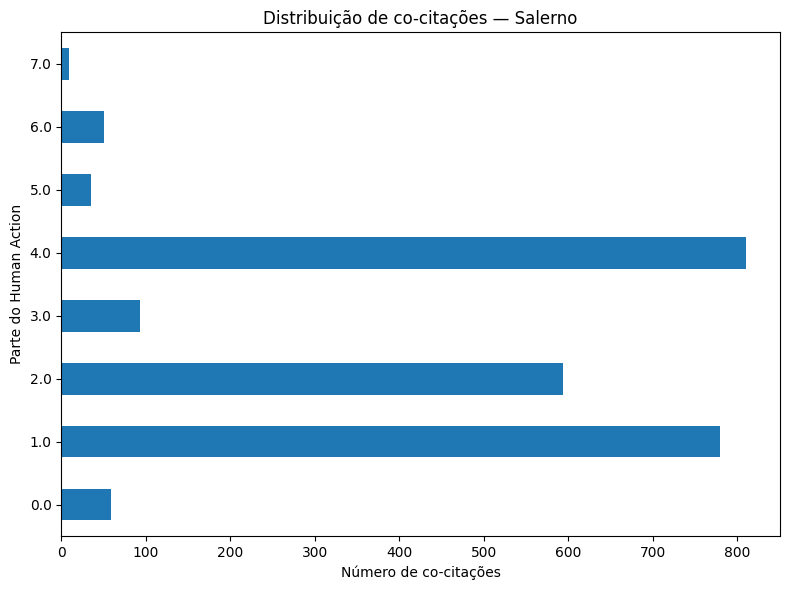

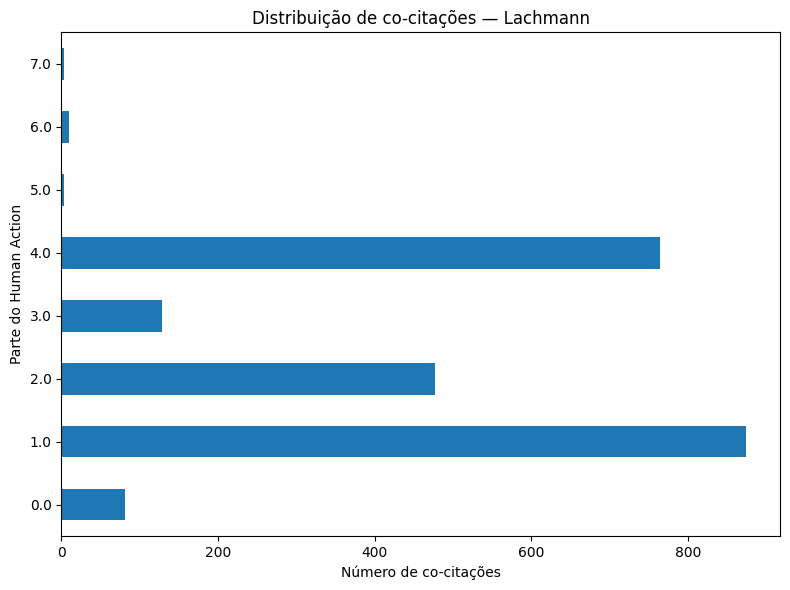

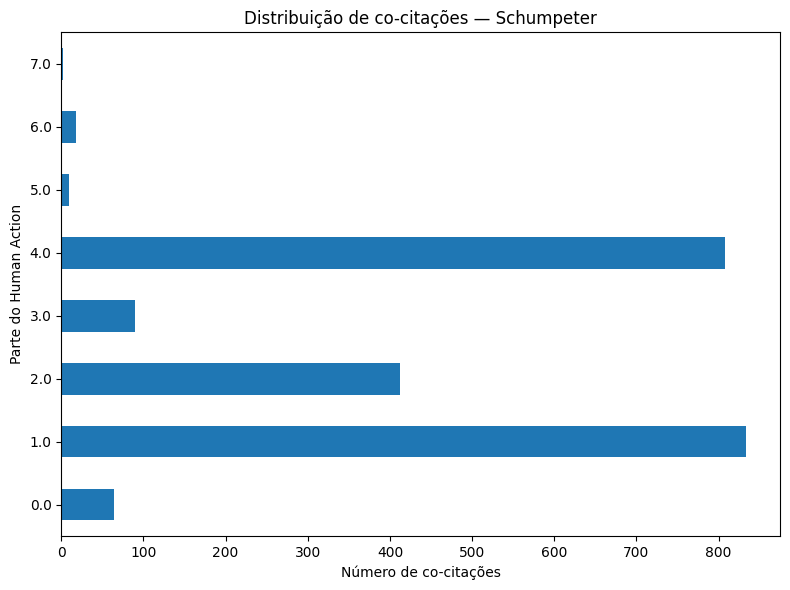

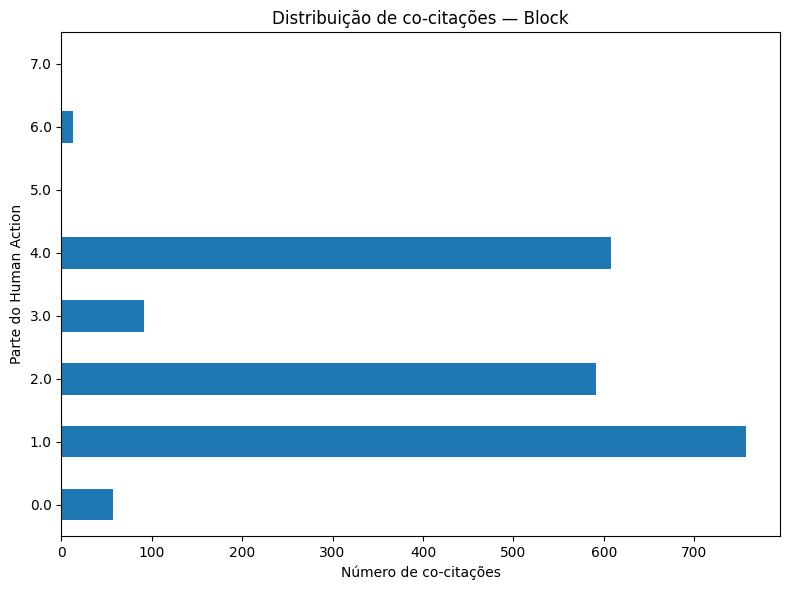

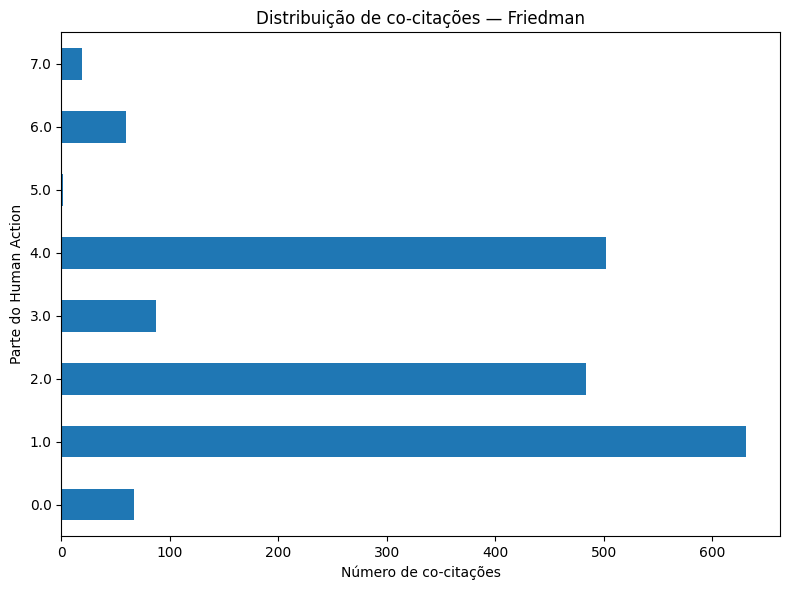

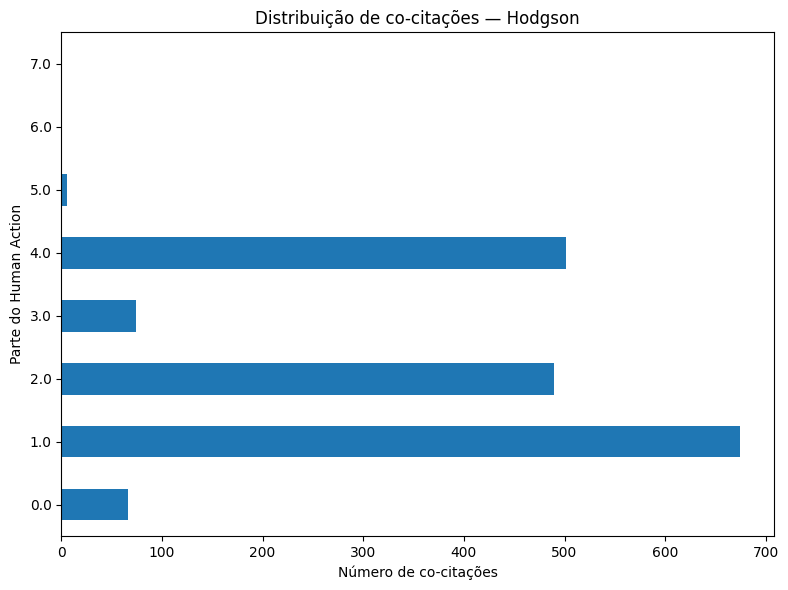

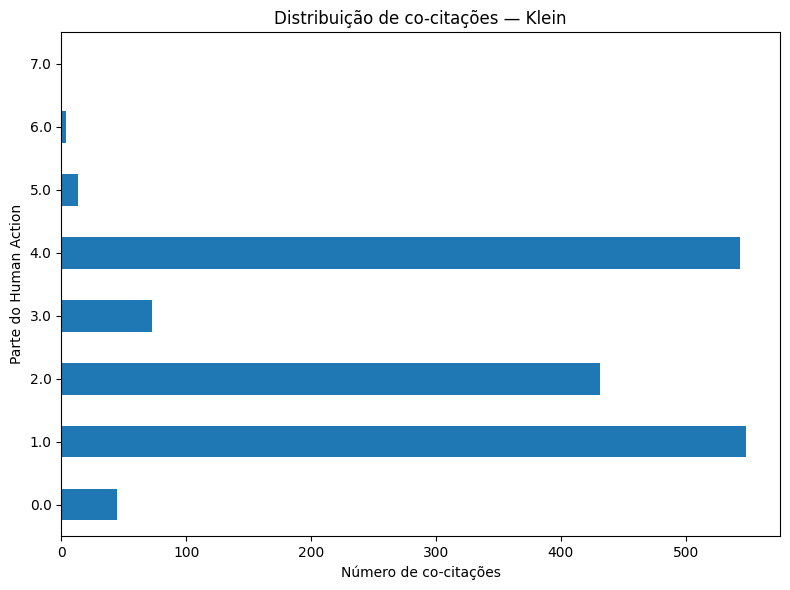

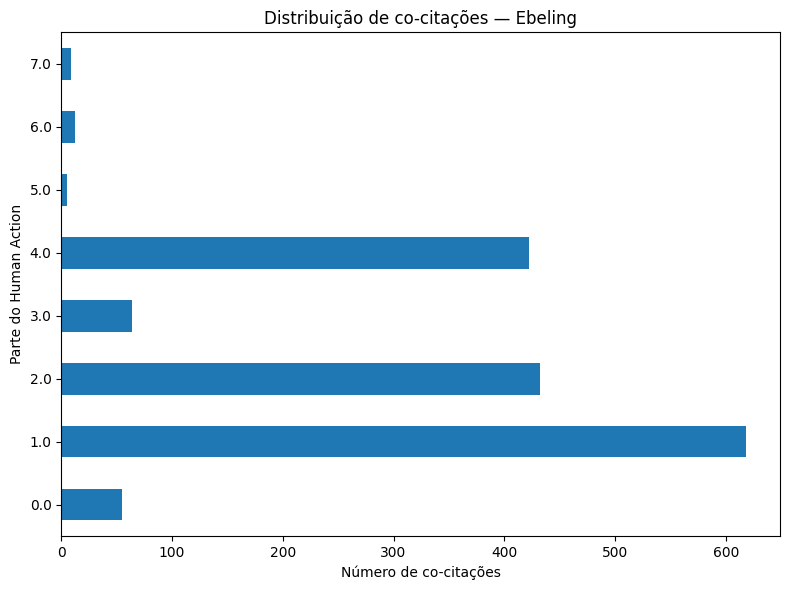

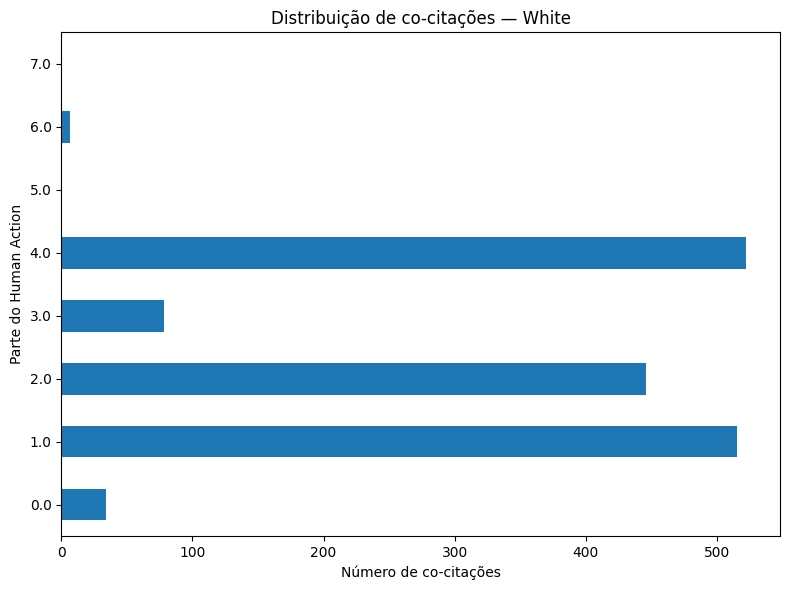

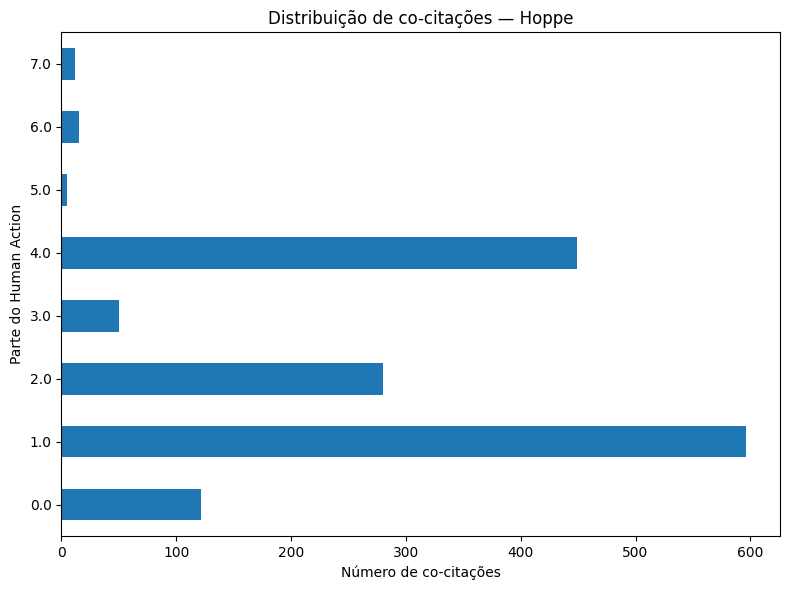

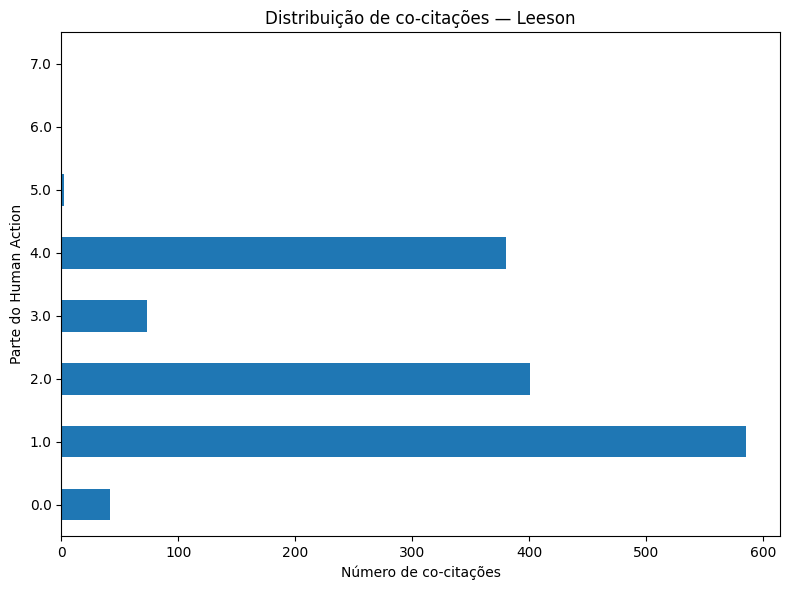

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

TOP_K = 20

# limpeza básica
df = pairs_df.dropna(subset=["human_action_part_number", "author_citation"])

# remove Mises
df = df[~df["author_citation"].str.lower().str.contains("mises")]

# garante que part é numérico
df["human_action_part_number"] = pd.to_numeric(
    df["human_action_part_number"], errors="coerce"
)

df = df.dropna(subset=["human_action_part_number"])

# --------------------------------------------------
# 1. identifica os TOP K autores (global)
# --------------------------------------------------
top_authors = (
    df["author_citation"]
    .value_counts()
    .head(TOP_K)
    .index
)

# partes em ordem numérica
parts = sorted(df["human_action_part_number"].unique())

# --------------------------------------------------
# 2. para cada autor, distribuição por parte
# --------------------------------------------------
for author in top_authors:
    author_df = df[df["author_citation"] == author]

    distribution = (
        author_df["human_action_part_number"]
        .value_counts()
        .reindex(parts, fill_value=0)  # garante todas as partes
        .sort_index()
    )

    if distribution.sum() == 0:
        continue

    plt.figure(figsize=(8, 4 + 0.25 * len(distribution)))
    distribution.plot(kind="barh")

    plt.title(f"Distribuição de co-citações — {author}")
    plt.xlabel("Número de co-citações")
    plt.ylabel("Parte do Human Action")

    plt.tight_layout()
    plt.show()
